# Pipeline Work

### Step 1: Connect to SQL + Prepare RDF Enviornment

In [ ]:
# Imports and global setup
import psycopg2
from rdflib import Graph, Namespace, RDF, RDFS, OWL, Literal
from Bio import Entrez
import re
import time

Entrez.email = "oresta.hewryk@pennmedicine.upenn.edu"  # Set your Entrez email

# SQL connection
conn = psycopg2.connect(
    host="romanodb1.pmacs.upenn.edu",
    port="5432",
    dbname="opendata",
    user="ohewryk",
    password="Sintra1005!",
    sslmode="prefer",
    gssencmode="disable"
)
cur = conn.cursor()

# Namespace
NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Utility for safe URIs
def sanitize_for_uri(text):
    return re.sub(r'\W|^(?=\d)', '_', text)


### Step 2: Load Ontology and Ensure 'Plant' Subclass Exists

In [ ]:
g = Graph()
g.parse("phytotherapies.rdf", format="xml")

# Ensure Plant subclass exists under PlantTaxonomy
if (NS.Plant, RDF.type, OWL.Class) not in g:
    g.add((NS.Plant, RDF.type, OWL.Class))
    g.add((NS.Plant, RDFS.subClassOf, NS.PlantTaxonomy))
    g.add((NS.Plant, RDFS.label, Literal("Plant")))

print("Plant class ready in ontology.")

### Step 3: Add Organism Individuals to Ontology

In [ ]:
import pickle
import time
from tqdm import tqdm
import requests
from rdflib import Literal

# --- Normalize names ---
def normalize_scientific_name(name):
    name = foname.strip()
    parts = name.split()
    if len(parts) >= 2:
        parts[0] = parts[0].capitalize()
        parts[1] = parts[1].lower()
        return f"{parts[0]} {parts[1]}"
    elif len(parts) == 1:
        return parts[0].capitalize()
    else:
        return ""

# --- Plant validation via POWO ---
def is_powo_plant(scientific_name):
    query = scientific_name.strip()
    url = f"https://powo.science.kew.org/api/2/search?q={query.replace(' ', '%20')}"
    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            data = response.json()
            if data.get("results"):
                for result in data["results"]:
                    if result["name"].lower() == query.lower():
                        return True
                return True
            else:
                return False
        else:
            return False
    except Exception as e:
        return False

# --- Plant validation via NCBI ---
def is_plantae(scientific_name):
    from Bio import Entrez
    Entrez.email = "your_email@domain.com"  # <-- use your real email
    try:
        search = Entrez.esearch(db="taxonomy", term=scientific_name)
        search_result = Entrez.read(search)
        search.close()
        if not search_result["IdList"]:
            return False
        tax_id = search_result["IdList"][0]
        fetch = Entrez.efetch(db="taxonomy", id=tax_id, retmode="xml")
        records = Entrez.read(fetch)
        fetch.close()
        rec = records[0]
        for rank in rec.get("LineageEx", []):
            if rank["Rank"].lower() == "kingdom" and (
                "plantae" in rank["ScientificName"].lower() or
                "viridiplantae" in rank["ScientificName"].lower()
            ):
                return True
        lineage_str = rec.get("Lineage", "").lower()
        if "plantae" in lineage_str or "viridiplantae" in lineage_str:
            return True
        return False
    except Exception as e:
        return False

# --- Load or initialize cache ---
try:
    with open("plant_validation_cache.pkl", "rb") as f:
        validation_cache = pickle.load(f)
except FileNotFoundError:
    validation_cache = {}

# --- Query for all organisms ---
cur.execute("SELECT id, name FROM coconut.organisms")
organisms = cur.fetchall()

added_orgs = 0

for org_id, name in tqdm(organisms):
    if not name:
        continue
    clean_name = normalize_scientific_name(name)
    cache_hit = clean_name in validation_cache
    if cache_hit:
        is_plant = validation_cache[clean_name]
    else:
        # Try NCBI first (faster); only POWO if needed
        is_plant = is_plantae(clean_name)
        if not is_plant:
            is_plant = is_powo_plant(clean_name)
        validation_cache[clean_name] = is_plant
        # Save progress every 100 new queries
        if len(validation_cache) % 100 == 0:
            with open("plant_validation_cache.pkl", "wb") as f:
                pickle.dump(validation_cache, f)
        time.sleep(0.2)  # Only sleep after API requests

    if is_plant:
        organism_uri = NS[f"Organism_{org_id}"]
        g.add((organism_uri, RDF.type, OWL.NamedIndividual))
        g.add((organism_uri, RDF.type, NS.Plant))
        g.add((organism_uri, RDFS.label, Literal(name)))
        added_orgs += 1

print(f"Total organisms added: {added_orgs}")

# Save final cache and ontology
with open("plant_validation_cache.pkl", "wb") as f:
    pickle.dump(validation_cache, f)
g.serialize("phytotherapies_augmented.rdf", format="xml")
print("Step 1 complete: Organisms added and ontology saved.")


In [ ]:
import copy

# Duplicate the ontology in memory
g_copy = copy.deepcopy(g)
print("Ontology duplicated in memory.")

# Save the duplicate as a new file
g_copy.serialize("phytotherapies_augmented_duplicate.rdf", format="xml")
print("Duplicate ontology file saved as 'phytotherapies_augmented_duplicate.rdf'.")


### Step 4: Load Augmented Ontology and Prepare Organism IDs

In [1]:
from rdflib import Graph, Namespace, RDF

# Load ontology (has schema + plant instances)
g = Graph()
g.parse("phytotherapies_augmented.rdf", format="xml")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Extract Organism IDs
loaded_organism_ids = set()
for s, p, o in g.triples((None, RDF.type, NS.Plant)):
    if str(s).startswith(str(NS["Organism_"])):
        try:
            loaded_organism_ids.add(int(str(s).split("_")[-1]))
        except ValueError:
            pass

print(f"Loaded organism IDs in ontology: {list(loaded_organism_ids)[:5]}")
print(f"Total loaded organism IDs: {len(loaded_organism_ids)}")


Loaded organism IDs in ontology: [1, 3, 4, 5, 6]
Total loaded organism IDs: 28062


## Step 5: Query Chemicals and All Needed Properties

In [3]:
import psycopg2

conn = psycopg2.connect(
    host="romanodb1.pmacs.upenn.edu",
    port="5432",
    dbname="opendata",
    user="ohewryk",
    password="Sintra1005!",
    sslmode="prefer",
    gssencmode="disable"
)
cur = conn.cursor()

cur.execute("""
    SELECT p.molecule_id, p.chemical_class, mo.organism_id, p.molecular_weight, p.molecular_formula,
           m.name AS molecule_name, m.iupac_name, e.canonical_smiles
    FROM coconut.properties p
    JOIN coconut.molecule_organism mo ON p.molecule_id = mo.molecule_id
    JOIN coconut.molecules m ON p.molecule_id = m.id
    JOIN coconut.entries e ON p.molecule_id = e.molecule_id
""")
property_links = cur.fetchall()
print(f"Total candidate chemical-organism links: {len(property_links)}")


Total candidate chemical-organism links: 9244455


### Step 6: Add Chemical Instances and Properties without Duplicates

In [9]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdflib import Graph, Namespace, RDF, RDFS, OWL, Literal

# === Load existing ontology ===
g = Graph()
g.parse("phytotherapies_augmented.rdf", format="xml")  # ← Your base ontology file

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Ontology properties
isDerivedFrom = NS.isDerivedFrom
hasMolecularWeight = NS.hasMolecularWeight
hasMolecularFormula = NS.hasMolecularFormula
hasCommonName = NS.hasCommonName
hasIUPACName = NS.hasIUPACName
hasSMILES = NS.hasSMILES

# Phytochemical subclasses of ChemicalConcept
phytochemical_classes = {
    "Carotenoid": NS.Carotenoid,
    "DietaryFiber": NS.DietaryFiber,
    "Isoprenoid": NS.Isoprenoid,
    "Phytosterol": NS.Phytosterol,
    "Polyphenol": NS.Polyphenol,
    "Polysaccharide": NS.Polysaccharide,
    "Saponin": NS.Saponin,
    "Unknown": NS.Unknown,
}

# === SMILES-based classifier ===
def classify_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ["Unknown"]

    classes = []

    mw = Descriptors.MolWt(mol)
    num_rings = Descriptors.RingCount(mol)
    num_oh = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OH]")))
    num_c = len([a for a in mol.GetAtoms() if a.GetSymbol() == "C"])
    num_o = len([a for a in mol.GetAtoms() if a.GetSymbol() == "O"])
    num_double_bonds = len(mol.GetSubstructMatches(Chem.MolFromSmarts("C=C")))

    if num_rings >= 2 and num_oh >= 2:
        classes.append("Polyphenol")
    if num_c >= 30 and num_double_bonds >= 5:
        classes.append("Carotenoid")
    if num_rings >= 4 and num_oh >= 1:
        classes.append("Phytosterol")
    if num_c >= 40 and num_o >= 5:
        classes.append("Saponin")
    if mw > 500 and num_o > 10:
        classes.append("Polysaccharide")
    if num_c > 20 and num_o > 15:
        classes.append("DietaryFiber")
    if "C=C" in smiles and num_c % 5 == 0:
        classes.append("Isoprenoid")

    return classes if classes else ["Unknown"]

# === Extract known organism IDs from data ===
loaded_organism_ids = {row[2] for row in property_links}
added_chemicals = set()
added_chems_count = 0
total_links = 0

# === Main RDF population loop ===
for (molecule_id, _db_class, organism_id, molecular_weight, molecular_formula,
     molecule_name, iupac_name, canonical_smiles) in property_links:

    if organism_id not in loaded_organism_ids:
        continue

    chem_uri = NS[f"Chemical_{molecule_id}"]
    org_uri = NS[f"Organism_{organism_id}"]

    if chem_uri not in added_chemicals:
        g.add((chem_uri, RDF.type, OWL.NamedIndividual))  # Do NOT add NS.Chemical

        if canonical_smiles:
            predicted_classes = classify_smiles(canonical_smiles)
        else:
            predicted_classes = ["Unknown"]

        for cls in predicted_classes:
            class_uri = phytochemical_classes.get(cls)
            if class_uri:
                g.add((chem_uri, RDF.type, class_uri))

        # Add literal data
        if molecular_weight is not None:
            g.add((chem_uri, hasMolecularWeight, Literal(molecular_weight)))
        if molecular_formula:
            g.add((chem_uri, hasMolecularFormula, Literal(molecular_formula)))
        if molecule_name:
            g.add((chem_uri, hasCommonName, Literal(molecule_name)))
        if iupac_name:
            g.add((chem_uri, hasIUPACName, Literal(iupac_name)))
        if canonical_smiles:
            g.add((chem_uri, hasSMILES, Literal(canonical_smiles)))
            g.add((chem_uri, RDFS.label, Literal(canonical_smiles)))  # Label using SMILES

        added_chemicals.add(chem_uri)
        added_chems_count += 1

    # Link to organism
    g.add((chem_uri, isDerivedFrom, org_uri))
    total_links += 1

# === Save enriched RDF without altering your ontology's schema ===
g.serialize("phytotherapies_augmented_enriched.rdf", format="xml")
print(f"Total unique chemicals added: {added_chems_count}")
print(f"Total chemical-organism links added: {total_links}")
print("Enriched ontology saved to phytotherapies_augmented_enriched.rdf")

[17:59:00] WARNING: not removing hydrogen atom without neighbors
[17:59:01] WARNING: not removing hydrogen atom without neighbors
[17:59:04] WARNING: not removing hydrogen atom without neighbors
[17:59:16] WARNING: not removing hydrogen atom without neighbors
[17:59:26] WARNING: not removing hydrogen atom without neighbors
[17:59:27] Explicit valence for atom # 20 N, 5, is greater than permitted
[17:59:29] WARNING: not removing hydrogen atom without neighbors
[17:59:34] WARNING: not removing hydrogen atom without neighbors
[17:59:41] WARNING: not removing hydrogen atom without neighbors
[17:59:41] WARNING: not removing hydrogen atom without neighbors
[17:59:41] WARNING: not removing hydrogen atom without neighbors
[17:59:44] Explicit valence for atom # 0 He, 2, is greater than permitted
[17:59:49] WARNING: not removing hydrogen atom without neighbors


Total unique chemicals added: 199649
Total chemical-organism links added: 9244455
Enriched ontology saved to phytotherapies_augmented_enriched.rdf


### Step 7: Save Final Ontology

In [11]:
g.serialize("phytotherapies_augmented_with_chemicals.rdf", format="xml")
print("Final ontology saved as phytotherapies_augmented_with_chemicals.rdf")

Final ontology saved as phytotherapies_augmented_with_chemicals.rdf


### Step 8: Review, Print Sample Triples (Optional)

In [12]:
print("Sample chemical triples:")
for s, p, o in g.triples((None, RDF.type, NS.Chemical)):
    for pp, oo in g.predicate_objects(s):
        print(f"{s} -- {pp} -- {oo}")
    print("---")
    break  # Show just the first for brevity

Sample chemical triples:


# Loading CMAUP data into Ontology

In [ ]:
# Turn CMAUPv2.0_download_Plant_Ingredient_Associations_allIngredients.txt into a .csv
import pandas as pd

# Load the tab-delimited file with no headers
df = pd.read_csv("CMAUPv2.0_download_Plant_Ingredient_Associations_allIngredients.txt", 
                 sep='\t', 
                 header=None,  # Treat the first row as data, not header
                 names=["Plant_ID", "Ingredient_ID"])  # Set column names

# Save as CSV
df.to_csv("step1.csv", index=False)

In [ ]:
#add plant names
import pandas as pd

# Read your step1.csv (which has Plant_ID, Ingredient_ID)
step1 = pd.read_csv("step1.csv")

# Read the plants file, assuming it's tab-delimited and has headers
plants = pd.read_csv("CMAUPv2.0_download_Plants.txt", sep='\t')

# Merge on 'Plant_ID'
merged = pd.merge(step1, plants[['Plant_ID', 'Plant_Name']], on='Plant_ID', how='left')

# Save to new CSV
merged.to_csv("step2.csv", index=False)


In [ ]:
#add targeted pathway (target_ID)
import pandas as pd

# Load step2.csv
step2 = pd.read_csv("step2.csv")

# Load Ingredient-Target file (assuming tab-delimited and has Ingredient_ID, Target_ID columns)
ingredient_target = pd.read_csv("CMAUPv2.0_download_Ingredient_Target_Associations_ActivityValues_References.txt", sep='\t')

# Merge on Ingredient_ID
merged = pd.merge(step2, ingredient_target[['Ingredient_ID', 'Target_ID']], on='Ingredient_ID', how='left')

# Save as step3.csv
merged.to_csv("step3.csv", index=False)


In [ ]:
#add common name (pref_name), molecular weight (MW), SMILES, and iupac_name
import pandas as pd

# Load step3.csv
step3 = pd.read_csv("step3.csv")

# Load the ingredients file (assuming tab-delimited and with headers)
ingredients = pd.read_csv("CMAUPv2.0_download_Ingredients_All (1).txt", sep='\t')

# Rename 'np_id' to 'Ingredient_ID' to enable merging
ingredients = ingredients.rename(columns={'np_id': 'Ingredient_ID'})

# Merge on Ingredient_ID, keeping only needed columns from ingredients
merged = pd.merge(
    step3,
    ingredients[['Ingredient_ID', 'pref_name', 'MW', 'SMILES', 'iupac_name']],
    on='Ingredient_ID',
    how='left'
)

# Save as step4.csv
merged.to_csv("step4.csv", index=False)


In [ ]:
#drop all duplicate rows

import pandas as pd

# Load the CSV
df = pd.read_csv("step4.csv")

# Remove duplicate rows (across all columns)
df_cleaned = df.drop_duplicates()

# Save the result
df_cleaned.to_csv("step5.csv", index=False)


In [ ]:
#replace Target_ID with TargetedPathway using NPASS data
import pandas as pd

# Load your deduplicated CSV
df = pd.read_csv("step4_deduped.csv")

# Load NPASS info
npass = pd.read_csv("NPASSv1.0_download_naturalProducts_targetInfo.txt", sep='\t')

# Create mapping: target_id → target_name
target_map = dict(zip(npass['target_id'], npass['target_name']))

# Replace Target_ID with TargetedPathway (mapped target name)
df['TargetedPathway'] = df['Target_ID'].map(target_map)

# Drop the original Target_ID column
df = df.drop(columns=['Target_ID'])

# Save as step6.csv
df.to_csv("step6.csv", index=False)

In [ ]:
#add molecular formula

import pandas as pd
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Load your file
df = pd.read_csv("step6.csv")

# Function to compute molecular formula from SMILES
def smiles_to_formula(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is not None:
            return rdMolDescriptors.CalcMolFormula(mol)
    except:
        return None
    return None

# Create new column with formula
df['Molecular_Formula'] = df['SMILES'].apply(smiles_to_formula)

# Save result
df.to_csv("step7.csv", index=False)



In [5]:
# Sorting compounds into phytochemical classes:

import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors

def classify_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return "Unknown"

    classes = []

    mw = Descriptors.MolWt(mol)
    num_rings = Descriptors.RingCount(mol)
    num_oh = len(mol.GetSubstructMatches(Chem.MolFromSmarts("[OH]")))
    num_c = len([atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'C'])
    num_o = len([atom for atom in mol.GetAtoms() if atom.GetSymbol() == 'O'])
    num_double_bonds = len(mol.GetSubstructMatches(Chem.MolFromSmarts("C=C")))

    # Heuristic rules (non-exclusive)
    if num_rings >= 2 and num_oh >= 2:
        classes.append("Polyphenol")
    if num_c >= 30 and num_double_bonds >= 5:
        classes.append("Carotenoid")
    if num_rings >= 4 and num_oh >= 1:
        classes.append("Phytosterol")
    if num_c >= 40 and num_o >= 5:
        classes.append("Saponin")
    if mw > 500 and num_o > 10:
        classes.append("Polysaccharide")
    if num_c > 20 and num_o > 15:
        classes.append("DietaryFiber")
    if "C=C" in smiles and num_c % 5 == 0:
        classes.append("Isoprenoid")

    if not classes:
        classes.append("Unknown")

    return ";".join(classes)

# Load input
df = pd.read_csv("step7.csv")
df = df.drop_duplicates(subset="SMILES")
df = df.dropna(subset=["SMILES"])
df["SMILES"] = df["SMILES"].astype(str)

# Multi-label classification
df['Phytochemical_Class'] = df['SMILES'].apply(classify_smiles)

# Save to new file
df.to_csv("step8.csv", index=False)



[16:45:48] Explicit valence for atom # 1 N, 5, is greater than permitted
[16:45:48] Explicit valence for atom # 15 S, 7, is greater than permitted
[16:45:48] Explicit valence for atom # 1 N, 4, is greater than permitted
[16:45:49] Can't kekulize mol.  Unkekulized atoms: 6 7 8 9 10 11 12 13 14
[16:45:49] Explicit valence for atom # 5 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 5 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 29 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 1 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 1 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 14 N, 5, is greater than permitted
[16:45:49] Explicit valence for atom # 8 N, 5, is greater than permitted
[16:45:49] Can't kekulize mol.  Unkekulized atoms: 6 9 10 11 12 13 14 15 19 20 21
[16:45:49] WARNING: not removing hydrogen atom without neighbors
[16:45:50] Explicit valence for atom # 6 C, 5,

In [17]:
#drop Plant_ID and Ingredient_ID from file and replace n.a. with blanks:

import pandas as pd

# Load the CSV
df = pd.read_csv("step8.csv")

# Drop the specified columns
df = df.drop(columns=["Plant_ID", "Ingredient_ID"], errors='ignore')

# Replace 'n.a.' strings with empty strings
df = df.replace("n.a.", "")

# Save to new CSV
df.to_csv("step9.csv", index=False)

### Loading all of this CMAUP data into the ontology

In [37]:
# Step 1: Load Existing Ontology
from rdflib import Graph, Namespace, RDF, RDFS, OWL, Literal

g = Graph()
g.parse("phytotherapies_augmented_with_chemicals.rdf", format="xml")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Object and data properties
isDerivedFrom = NS.isDerivedFrom
hasMolecularWeight = NS.hasMolecularWeight
hasMolecularFormula = NS.hasMolecularFormula
hasCommonName = NS.hasCommonName
hasIUPACName = NS.hasIUPACName
hasSMILES = NS.hasSMILES

# Subclasses of ChemicalConcept
phytochemical_classes = {
    "Carotenoid": NS.Carotenoid,
    "DietaryFiber": NS.DietaryFiber,
    "Isoprenoid": NS.Isoprenoid,
    "Phytosterol": NS.Phytosterol,
    "Polyphenol": NS.Polyphenol,
    "Polysaccharide": NS.Polysaccharide,
    "Saponin": NS.Saponin,
    "Unknown": NS.Unknown,
}

In [43]:
# Step 2: Load and Clean CSV
import pandas as pd

na_values = ["", "nan", "NaN", "NAN"]
df9 = pd.read_csv("step9.csv", na_values=na_values)
df9 = df9.dropna(subset=["SMILES", "Phytochemical_Class", "Plant_Name"])
df9["SMILES"] = df9["SMILES"].astype(str).str.strip()
df9["Phytochemical_Class"] = df9["Phytochemical_Class"].astype(str).str.strip()
df9["Plant_Name"] = df9["Plant_Name"].astype(str).str.strip()
df9["Molecular_Formula"] = df9["Molecular_Formula"].astype(str).str.strip()
df9["iupac_name"] = df9["iupac_name"].astype(str).str.strip()
df9["pref_name"] = df9["pref_name"].astype(str).str.strip()
df9["MW"] = pd.to_numeric(df9["MW"], errors="coerce")

df9 = df9.drop_duplicates(subset=["SMILES"])

In [27]:
# Step 3: Add Plant Instances
existing_plant_names = {
    str(o).strip().lower()
    for s, p, o in g.triples((None, RDF.type, NS.Plant))
    if isinstance(s, Namespace)
}

added_plants = 0
for plant_name in df9["Plant_Name"].dropna().drop_duplicates():
    norm_name = plant_name.strip()
    if norm_name.lower() in existing_plant_names:
        continue

    plant_uri = NS[f"Plant_{norm_name.replace(' ', '_')}"]
    g.add((plant_uri, RDF.type, OWL.NamedIndividual))
    g.add((plant_uri, RDF.type, NS.Plant))
    g.add((plant_uri, RDFS.label, Literal(norm_name)))
    added_plants += 1

print(f"New plants added: {added_plants}")

New plants added: 3928


In [45]:
# Step 4: Add Chemical Instances and Data Properties
existing_smiles = {
    str(o).strip() for s, p, o in g.triples((None, hasSMILES, None))
}

added_chemicals = 0
for _, row in df9.iterrows():
    smiles = row["SMILES"]
    if smiles in existing_smiles:
        continue

    chem_uri = NS[f"Chemical_{abs(hash(smiles))}"]
    g.add((chem_uri, RDF.type, OWL.NamedIndividual))

    for cls in row["Phytochemical_Class"].split(";"):
        class_uri = phytochemical_classes.get(cls.strip())
        if class_uri:
            g.add((chem_uri, RDF.type, class_uri))

    g.add((chem_uri, hasSMILES, Literal(smiles)))
    g.add((chem_uri, RDFS.label, Literal(smiles)))

    if pd.notna(row["MW"]):
        g.add((chem_uri, hasMolecularWeight, Literal(row["MW"])))
    if pd.notna(row["Molecular_Formula"]):
        g.add((chem_uri, hasMolecularFormula, Literal(row["Molecular_Formula"])))
    if pd.notna(row["iupac_name"]):
        g.add((chem_uri, hasIUPACName, Literal(row["iupac_name"])))
    if pd.notna(row["pref_name"]):
        g.add((chem_uri, hasCommonName, Literal(row["pref_name"])))

    added_chemicals += 1
    existing_smiles.add(smiles)

print(f"New chemical instances added: {added_chemicals}")

New chemical instances added: 56918


In [47]:
# Step 5: Add isDerivedFrom Links
existing_links = {
    (str(s), str(o))
    for s, p, o in g.triples((None, isDerivedFrom, None))
}

new_links = 0
for _, row in df9.iterrows():
    smiles = row["SMILES"]
    plant_name = row["Plant_Name"]
    chem_uri = NS[f"Chemical_{abs(hash(smiles))}"]
    plant_uri = NS[f"Plant_{plant_name.replace(' ', '_')}"]

    if (str(chem_uri), str(plant_uri)) not in existing_links:
        g.add((chem_uri, isDerivedFrom, plant_uri))
        existing_links.add((str(chem_uri), str(plant_uri)))
        new_links += 1

print(f"New isDerivedFrom links added: {new_links}")


New isDerivedFrom links added: 59362


In [49]:
# Step 6: Save Updated Ontology
g.serialize("phytotherapies_augmented_COCONUT_CMAUP.rdf", format="xml")
print("Ontology saved to phytotherapies_augmented_enriched.rdf")

Ontology saved to phytotherapies_augmented_enriched.rdf


### Adding MACCs Keys to Ontology

In [33]:
from rdflib import Graph, Namespace, RDF, RDFS, OWL, Literal
from rdkit import Chem
from rdkit.Chem import MACCSkeys

# Load existing ontology
g = Graph()
g.parse("phytotherapies_augmented_COCONUT_CMAUP.rdf", format="xml")

# Define namespace
NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Data properties
hasSMILES = NS.hasSMILES
hasMACCs = NS.hasMACCs

# Subclasses of ChemicalConcept (manually listed since they’re not queried dynamically)
phytochemical_classes = {
    "Carotenoid": NS.Carotenoid,
    "DietaryFiber": NS.DietaryFiber,
    "Isoprenoid": NS.Isoprenoid,
    "Phytosterol": NS.Phytosterol,
    "Polyphenol": NS.Polyphenol,
    "Polysaccharide": NS.Polysaccharide,
    "Saponin": NS.Saponin,
    "Unknown": NS.Unknown,
}
chemical_classes = set(phytochemical_classes.values())

# Add MACCS to each relevant chemical individual
added_maccs = 0
for s, p, o in g.triples((None, RDF.type, None)):
    if o in chemical_classes:
        chem_uri = s

        # Skip if MACCS already exists
        if (chem_uri, hasMACCs, None) in g:
            continue

        # Get SMILES
        smiles = None
        for _, _, smile_obj in g.triples((chem_uri, hasSMILES, None)):
            smiles = str(smile_obj).strip()
            break

        if not smiles:
            continue

        mol = Chem.MolFromSmiles(smiles)
        if mol:
            maccs_fp = MACCSkeys.GenMACCSKeys(mol)
            maccs_str = maccs_fp.ToBitString()
            g.add((chem_uri, hasMACCs, Literal(maccs_str)))
            added_maccs += 1

print(f"MACCS keys added for {added_maccs} chemical instances.")

# Save updated ontology
g.serialize("phytotherapies_COCONUT_CMAUP_MACCS.rdf", format="xml")
print("Updated ontology saved to phytotherapies_COCONUT_CMAUP_MACCS.rdf")


[16:16:40] WARNING: not removing hydrogen atom without neighbors
[16:16:40] WARNING: not removing hydrogen atom without neighbors
[16:17:00] WARNING: not removing hydrogen atom without neighbors
[16:17:05] WARNING: not removing hydrogen atom without neighbors
[16:17:05] WARNING: not removing hydrogen atom without neighbors
[16:17:08] WARNING: not removing hydrogen atom without neighbors
[16:17:17] Explicit valence for atom # 8 N, 5, is greater than permitted
[16:17:17] Explicit valence for atom # 29 N, 5, is greater than permitted
[16:17:17] Explicit valence for atom # 7 N, 5, is greater than permitted
[16:17:19] Explicit valence for atom # 15 S, 7, is greater than permitted
[16:17:19] Explicit valence for atom # 14 N, 5, is greater than permitted
[16:17:22] Explicit valence for atom # 22 N, 4, is greater than permitted
[16:17:23] Can't kekulize mol.  Unkekulized atoms: 11 12 13
[16:17:25] Explicit valence for atom # 20 N, 4, is greater than permitted
[16:17:25] Explicit valence for at

MACCS keys added for 256533 chemical instances.
Updated ontology saved to phytotherapies_COCONUT_CMAUP_MACCS.rdf


Takes SMILES strings in my ontology run through drug central SQL and their respective 'target name' to be added as an instance in ontology under 'TargetedPathway'.

In [31]:
from rdflib import Graph, Namespace, Literal
from rdflib.namespace import RDF
import pandas as pd
import psycopg2
from rdkit import Chem
from tqdm import tqdm

g = Graph()
g.parse("phytotherapies_COCONUT_CMAUP_MACCS_ATC.rdf")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
hasSMILES = NS.hasSMILES
hasInChIKey = NS.hasInChIKey
TherapeuticEffect = NS.TherapeuticEffect
TargetedPathway = NS.TargetedPathway
hasTherapeuticEffect = NS.hasTherapeuticEffect
targetsPathway = NS.targetsPathway
hasValue = NS.hasValue  # For storing string value in instance


In [9]:
import pandas as pd
import psycopg2
from rdkit import Chem
from tqdm import tqdm
from rdflib import Graph, Namespace, Literal
from rdflib.namespace import RDF
import re

# 1. URI-safe function for names
def uri_safe(s):
    s = re.sub(r'\W+', '_', str(s))
    s = re.sub(r'_+', '_', s)
    return s.strip('_')

# 2. Load ontology
g = Graph()
g.parse("phytotherapies_COCONUT_CMAUP_MACCS_ATC.rdf")

# 3. Setup Namespace and Properties
NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
hasSMILES = NS.hasSMILES
hasInChIKey = NS.hasInChIKey
TherapeuticEffect = NS.TherapeuticEffect
TargetedPathway = NS.TargetedPathway
hasTherapeuticEffect = NS.hasTherapeuticEffect
targetsPathway = NS.targetsPathway
hasValue = NS.hasValue

# 4. Extract SMILES and map to subject
chemical_smiles = []
smiles_to_subject = {}
for subj, pred, obj in g.triples((None, hasSMILES, None)):
    smiles = str(obj)
    chemical_smiles.append(smiles)
    smiles_to_subject[smiles] = subj

# 5. Generate InChIKeys for all SMILES
def smiles_to_inchikey(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToInchiKey(mol) if mol else None

smiles_inchikey = {}
for s in tqdm(chemical_smiles, desc="Converting SMILES to InChIKey"):
    ik = smiles_to_inchikey(s)
    if ik:
        smiles_inchikey[s] = ik
inchikeys = list(smiles_inchikey.values())

# 6. Add InChIKey as data property for each subject (for easier linking)
for smiles, subj in smiles_to_subject.items():
    ik = smiles_inchikey.get(smiles)
    if ik:
        g.add((subj, hasInChIKey, Literal(ik)))

# 7. Build InChIKey→subject mapping
inchikey_to_subject = {}
for subj, pred, obj in g.triples((None, hasInChIKey, None)):
    inchikey_to_subject[str(obj)] = subj

# 8. Query DrugCentral for action_type and Targets
with psycopg2.connect(
    host="unmtid-dbs.net",
    port=5433,
    dbname="drugcentral",
    user="drugman",
    password="dosage"
) as conn:
    # Get action_type as TherapeuticEffect
    action_type_query = """
        SELECT s.inchikey, atf.action_type
        FROM structures s
        JOIN act_table_full atf ON s.id = atf.struct_id
        WHERE s.inchikey = ANY(%s) AND atf.action_type IS NOT NULL
    """
    action_type_df = pd.read_sql(action_type_query, conn, params=(inchikeys,))

    target_query = """
        SELECT s.inchikey, td.name AS target
        FROM structures s
        JOIN act_table_full atf ON s.id = atf.struct_id
        JOIN target_dictionary td ON atf.target_id = td.id
        WHERE s.inchikey = ANY(%s)
    """
    target_df = pd.read_sql(target_query, conn, params=(inchikeys,))

print(f"TherapeuticEffect/action_type records found: {len(action_type_df)}")
print(f"Target records found: {len(target_df)}")

# 9. Enrich Ontology: Add TherapeuticEffect (action_type) and Target instances, link to compounds
effect_instances = {}
target_instances = {}

for idx, row in tqdm(action_type_df.iterrows(), total=len(action_type_df), desc="Enriching action_type"):
    ikey = row['inchikey']
    effect = row['action_type']
    subj = inchikey_to_subject.get(ikey)
    if not subj or pd.isnull(effect):
        continue
    effect_uri = NS[uri_safe(effect)]
    if effect not in effect_instances:
        g.add((effect_uri, RDF.type, TherapeuticEffect))
        g.add((effect_uri, hasValue, Literal(effect)))
        effect_instances[effect] = effect_uri
    g.add((subj, hasTherapeuticEffect, effect_instances[effect]))

for idx, row in tqdm(target_df.iterrows(), total=len(target_df), desc="Enriching Targets"):
    ikey = row['inchikey']
    target = row['target']
    subj = inchikey_to_subject.get(ikey)
    if not subj or pd.isnull(target):
        continue
    target_uri = NS[uri_safe(target)]
    if target not in target_instances:
        g.add((target_uri, RDF.type, TargetedPathway))
        g.add((target_uri, hasValue, Literal(target)))
        target_instances[target] = target_uri
    g.add((subj, targetsPathway, target_instances[target]))

# 10. Serialize the enriched ontology
g.serialize(destination="phytotherapies_enriched_with_actiontype_targets.rdf", format="xml")
print("Enriched ontology saved to phytotherapies_enriched_with_actiontype_targets.rdf")

Converting SMILES to InChIKey:  29%|▊  | 74148/256567 [00:12<00:29, 6122.73it/s][11:05:24] WARNING: not removing hydrogen atom without neighbors
[11:05:24] Explicit valence for atom # 7 S, 7, is greater than permitted
Converting SMILES to InChIKey:  46%|▉ | 117487/256567 [00:19<00:21, 6477.03it/s][11:05:31] unrecognized chirality tag (6) on atom 1 is ignored.
[11:05:31] unrecognized chirality tag (6) on atom 14 is ignored.
Converting SMILES to InChIKey:  51%|█ | 131609/256567 [00:21<00:20, 6206.00it/s][11:05:33] WARNING: not removing hydrogen atom without neighbors
[11:05:33] WARNING: not removing hydrogen atom without neighbors
[11:05:33] WARNING: not removing hydrogen atom without neighbors
[11:05:33] Explicit valence for atom # 5 N, 5, is greater than permitted
Converting SMILES to InChIKey: 100%|█▉| 255651/256567 [00:40<00:00, 6936.81it/s][11:05:52] Explicit valence for atom # 1 N, 5, is greater than permitted
[11:05:52] Explicit valence for atom # 1 N, 4, is greater than permitted

TherapeuticEffect/action_type records found: 883
Target records found: 6160


Enriching Targets: 100%|█████████████████| 6160/6160 [00:00<00:00, 48843.91it/s]


Enriched ontology saved to phytotherapies_enriched_with_actiontype_targets.rdf


Add ATC codes o drug central data in ontology

In [11]:
import pandas as pd
import psycopg2
from rdflib import Graph, Namespace, Literal

# Load the ontology you want to enrich
g = Graph()
g.parse("phytotherapies_enriched_with_actiontype_targets.rdf")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
hasATC = NS.hasATC
hasTherapeuticEffect = NS.hasTherapeuticEffect
targetsPathway = NS.targetsPathway
hasInChIKey = NS.hasInChIKey

# Find chemicals with a therapeutic effect or targeted pathway
chem_with_moa_or_target = set()
for subj, pred, obj in g.triples((None, hasTherapeuticEffect, None)):
    chem_with_moa_or_target.add(subj)
for subj, pred, obj in g.triples((None, targetsPathway, None)):
    chem_with_moa_or_target.add(subj)

# Get their InChIKeys
inchikeys_to_query = []
for subj in chem_with_moa_or_target:
    for s, p, o in g.triples((subj, hasInChIKey, None)):
        inchikeys_to_query.append(str(o))
inchikeys_to_query = list(set(inchikeys_to_query))

# Query DrugCentral for ATC codes
with psycopg2.connect(
    host="unmtid-dbs.net",
    port=5433,
    dbname="drugcentral",
    user="drugman",
    password="dosage"
) as conn:
    atc_query = """
        SELECT s.inchikey, a.code AS atc_code
        FROM structures s
        JOIN struct2atc s2a ON s.id = s2a.struct_id
        JOIN atc a ON s2a.atc_code = a.code
        WHERE s.inchikey = ANY(%s)
    """
    atc_df = pd.read_sql(atc_query, conn, params=(inchikeys_to_query,))

# Map InChIKey to ontology subject
inchikey_to_subject = {}
for subj, pred, obj in g.triples((None, hasInChIKey, None)):
    inchikey_to_subject[str(obj)] = subj

# Add ATC code(s) as data property
for idx, row in atc_df.iterrows():
    ikey = row['inchikey']
    atc = row['atc_code']
    subj = inchikey_to_subject.get(ikey)
    if subj and atc:
        g.add((subj, hasATC, Literal(atc)))

# Save ontology
g.serialize(destination="phytotherapies_enriched_with_actiontype_targets_ATC.rdf", format="xml")
print("Ontology with ATC codes saved to phytotherapies_enriched_with_actiontype_targets_ATC.rdf")



/var/folders/hf/k8cxlyt50fn8c7rnk_g8v1l00000gq/T/ipykernel_11549/4198725557.py:44: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  atc_df = pd.read_sql(atc_query, conn, params=(inchikeys_to_query,))


Ontology with ATC codes saved to phytotherapies_enriched_with_actiontype_targets_ATC.rdf


## Adding more mechanisms of action from ChEMBL data

Download .csv file from ChEMBL Drug Mechanisms page (https://www.ebi.ac.uk/chembl/explore/drug_mechanisms/), use it to find mechanism of action for more compounds in ontology.

In [13]:
from rdflib import Graph, Namespace, Literal
from rdflib.namespace import RDF
import pandas as pd
import psycopg2
from rdkit import Chem
from tqdm import tqdm

In [15]:
df = pd.read_csv("ChEMBL_drug_mechanisms.csv", sep=';')

print(df.head(5))

  Parent Molecule ChEMBL ID             Parent Molecule Name  \
0             CHEMBL1201185                       LANREOTIDE   
1             CHEMBL1201468            ESTROGENS, ESTERIFIED   
2             CHEMBL1090479                      GSK-1070916   
3             CHEMBL1201640  INSULIN ZINC SUSP EXTENDED BEEF   
4             CHEMBL3707247                         OZANIMOD   

  Parent Molecule Type  Max Phase  First Approval        USAN Stem  \
0              Protein        4.0          2007.0          '-tide'   
1              Unknown        4.0          1977.0  'estr-; -ster-'   
2       Small molecule        1.0             NaN              NaN   
3              Protein        4.0          1982.0              NaN   
4       Small molecule        4.0          2020.0          '-imod'   

                                              Smiles  \
0  CC(C)[C@@H]1NC(=O)[C@H](CCCCN)NC(=O)[C@@H](Cc2...   
1                                                NaN   
2  CCn1cc(-c2ccnc3[nH]c(-c

From the file ChEMBL_drug_mechanisms.csv, take the values in column 'Target Name' that have SMILES that correspond to the instances under ChemicalConcept in my ontology (which are also SMILES) and add them to my ontolgy as instances in the class 'TargetedPathway'. Make sure there are no duplicate instances, as multiple instances can be connected to each other. Connect the instances under ChemicalConcept to their respective TargetedPathway instance(s) using the object property 'targetsPathway'.

From the file ChEMBL_drug_mechanisms.csv, also take the values in column 'Action Type' that have SMILES that correspond to the instances under ChemicalConcept in my ontology (which are also SMILES) and add them to my ontolgy as instances in the class 'TherapeuticEffect'. Make sure there are no duplicate instances, as multiple instances can be connected to each other. Connect the instances under ChemicalConcept to their respective TherapeuticEffect instance(s) using the object property 'hasTherapeuticEffect'.

My ontology is titled 'phytotherapies_enriched_with_actiontype_targets_ATC.rdf'

In [21]:
import pandas as pd
from rdflib import Graph, Namespace, Literal
from rdflib.namespace import RDF
import re

# Utility for URI-safety
def uri_safe(s):
    s = re.sub(r'\W+', '_', str(s))
    s = re.sub(r'_+', '_', s)
    return s.strip('_')

# Load ontology
g = Graph()
g.parse("phytotherapies_enriched_with_actiontype_targets_ATC.rdf")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
ChemicalConcept = NS.ChemicalConcept
TargetedPathway = NS.TargetedPathway
TherapeuticEffect = NS.TherapeuticEffect
hasSMILES = NS.hasSMILES
targetsPathway = NS.targetsPathway
hasTherapeuticEffect = NS.hasTherapeuticEffect
hasValue = NS.hasValue

# Get SMILES for all ChemicalConcept instances
chemicalconcept_smiles_to_subject = {}
for subj in g.subjects(RDF.type, ChemicalConcept):
    for s, p, o in g.triples((subj, hasSMILES, None)):
        smiles = str(o)
        chemicalconcept_smiles_to_subject[smiles] = subj

# Load ChEMBL drug mechanisms CSV
df = pd.read_csv("ChEMBL_drug_mechanisms.csv", sep=';')

# Optionally: Standardize SMILES if necessary (strip whitespace, upper/lower)
df['Smiles'] = df['Smiles'].astype(str).str.strip()

# Prepare instance maps to avoid duplicates
pathway_instances = {}
effect_instances = {}

added_target_triples = 0
added_effect_triples = 0

for idx, row in df.iterrows():
    smiles = row['Smiles'].strip()
    subj = chemicalconcept_smiles_to_subject.get(smiles)
    if subj is None:
        continue

    # TargetedPathway enrichment
    target_name = str(row['Target Name']).strip()
    if target_name and target_name != "nan":
        pathway_uri = NS[uri_safe(target_name)]
        if target_name not in pathway_instances:
            g.add((pathway_uri, RDF.type, TargetedPathway))
            g.add((pathway_uri, hasValue, Literal(target_name)))
            pathway_instances[target_name] = pathway_uri
        g.add((subj, targetsPathway, pathway_instances[target_name]))
        added_target_triples += 1

    # TherapeuticEffect enrichment
    action_type = str(row['Action Type']).strip()
    if action_type and action_type != "nan":
        effect_uri = NS[uri_safe(action_type)]
        if action_type not in effect_instances:
            g.add((effect_uri, RDF.type, TherapeuticEffect))
            g.add((effect_uri, hasValue, Literal(action_type)))
            effect_instances[action_type] = effect_uri
        g.add((subj, hasTherapeuticEffect, effect_instances[action_type]))
        added_effect_triples += 1

print(f"Added {added_target_triples} targetsPathway triples.")
print(f"Added {added_effect_triples} hasTherapeuticEffect triples.")

# Save the enriched ontology
g.serialize(destination="phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf", format="xml")
print("Saved as 'phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf'")

Added 0 targetsPathway triples.
Added 0 hasTherapeuticEffect triples.
Saved as 'phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf'


In [23]:
print("Ontology SMILES examples:", list(chemicalconcept_smiles_to_subject.keys())[:5])
print("ChEMBL CSV SMILES examples:", df['Smiles'].unique()[:5])


Ontology SMILES examples: []
ChEMBL CSV SMILES examples: ['CC(C)[C@@H]1NC(=O)[C@H](CCCCN)NC(=O)[C@@H](Cc2c[nH]c3ccccc23)NC(=O)[C@H](Cc2ccc(O)cc2)NC(=O)[C@@H](NC(=O)[C@H](N)Cc2ccc3ccccc3c2)CSSC[C@@H](C(=O)N[C@H](C(N)=O)[C@@H](C)O)NC1=O'
 'nan'
 'CCn1cc(-c2ccnc3[nH]c(-c4cccc(CN(C)C)c4)cc23)c(-c2ccc(NC(=O)N(C)C)cc2)n1'
 'CC(C)Oc1ccc(-c2nc(-c3cccc4c3CC[C@@H]4NCCO)no2)cc1C#N'
 'CC(N)C(O)c1ccccc1']


In [29]:
import pandas as pd
from rdkit import Chem
from rdflib import Graph, Namespace, Literal
from rdflib.namespace import RDF
import re

def uri_safe(s):
    s = re.sub(r'\W+', '_', str(s))
    s = re.sub(r'_+', '_', s)
    return s.strip('_')

# Load ontology
g = Graph()
g.parse("phytotherapies_enriched_with_actiontype_targets_ATC.rdf")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
hasSMILES = NS.hasSMILES
TherapeuticEffect = NS.TherapeuticEffect
TargetedPathway = NS.TargetedPathway
hasTherapeuticEffect = NS.hasTherapeuticEffect
targetsPathway = NS.targetsPathway
hasValue = NS.hasValue

# 1. Extract SMILES from ontology, map to subject
chemicalconcept_smiles_to_subject = {}
for subj, pred, obj in g.triples((None, hasSMILES, None)):
    chemicalconcept_smiles_to_subject[str(obj)] = subj

# 2. Canonicalize ontology SMILES for matching
def canonicalize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

canonical_smiles_to_subject = {}
for smi, subj in chemicalconcept_smiles_to_subject.items():
    can = canonicalize_smiles(smi)
    if can:
        canonical_smiles_to_subject[can] = subj

# 3. Read ChEMBL CSV
df = pd.read_csv("ChEMBL_drug_mechanisms.csv", sep=';')
df['Smiles'] = df['Smiles'].astype(str).str.strip()
df['Smiles_canonical'] = df['Smiles'].apply(canonicalize_smiles)

# 4. Prepare maps to avoid duplicate instances
effect_instances = {}
pathway_instances = {}
count_target = 0
count_effect = 0

for idx, row in df.iterrows():
    can = row['Smiles_canonical']
    if not can or can not in canonical_smiles_to_subject:
        continue
    subj = canonical_smiles_to_subject[can]

    # TargetedPathway: Target Name
    tname = str(row.get('Target Name', '')).strip()
    if tname and tname != 'nan':
        t_uri = NS[uri_safe(tname)]
        if tname not in pathway_instances:
            g.add((t_uri, RDF.type, TargetedPathway))
            g.add((t_uri, hasValue, Literal(tname)))
            pathway_instances[tname] = t_uri
        g.add((subj, targetsPathway, pathway_instances[tname]))
        count_target += 1

    # TherapeuticEffect: Action Type
    ename = str(row.get('Action Type', '')).strip()
    if ename and ename != 'nan':
        e_uri = NS[uri_safe(ename)]
        if ename not in effect_instances:
            g.add((e_uri, RDF.type, TherapeuticEffect))
            g.add((e_uri, hasValue, Literal(ename)))
            effect_instances[ename] = e_uri
        g.add((subj, hasTherapeuticEffect, effect_instances[ename]))
        count_effect += 1

print(f"Added {count_target} targetsPathway triples.")
print(f"Added {count_effect} hasTherapeuticEffect triples.")

# Save the new enriched ontology
g.serialize(destination="phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf", format="xml")
print("Saved as 'phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf'")


[12:44:53] Can't kekulize mol.  Unkekulized atoms: 2 3 7 8 9 10 11 12 16 17 18 19
[12:44:54] WARNING: not removing hydrogen atom without neighbors
[12:44:55] Explicit valence for atom # 8 N, 5, is greater than permitted
[12:44:55] Explicit valence for atom # 1 N, 5, is greater than permitted
[12:44:56] Explicit valence for atom # 1 N, 5, is greater than permitted
[12:44:56] Explicit valence for atom # 14 N, 5, is greater than permitted
[12:44:57] Explicit valence for atom # 1 N, 4, is greater than permitted
[12:44:57] WARNING: not removing hydrogen atom without neighbors
[12:44:58] Explicit valence for atom # 1 N, 5, is greater than permitted
[12:45:00] Explicit valence for atom # 1 N, 5, is greater than permitted
[12:45:01] WARNING: not removing hydrogen atom without neighbors
[12:45:01] WARNING: not removing hydrogen atom without neighbors
[12:45:01] WARNING: not removing hydrogen atom without neighbors
[12:45:01] WARNING: not removing hydrogen atom without neighbors
[12:45:03] Expli

Added 420 targetsPathway triples.
Added 420 hasTherapeuticEffect triples.
Saved as 'phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf'


Adding ATC codes to ChEMBL-enriched data

In [75]:
from rdflib import Graph, Namespace, Literal

# 1. Load ontology (update filename as needed)
g = Graph()
g.parse("phytotherapies_final_enriched_with_ChEMBL_mechanisms.rdf")

NS = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")
hasInChIKey = NS.hasInChIKey
hasATC = NS.hasATC
targetsPathway = NS.targetsPathway
hasTherapeuticEffect = NS.hasTherapeuticEffect

# 2. Get subjects enriched with ChEMBL
enriched_subjects = set()
for s, p, o in g.triples((None, targetsPathway, None)):
    enriched_subjects.add(s)
for s, p, o in g.triples((None, hasTherapeuticEffect, None)):
    enriched_subjects.add(s)

# 3. Map those subjects to their InChIKeys
enriched_subjects_inchikeys = {}
for s in enriched_subjects:
    for _, _, o in g.triples((s, hasInChIKey, None)):
        enriched_subjects_inchikeys[s] = str(o)

# 4. Build InChIKey → subject map for enrichment
inchikey_to_enriched_subject = {v: k for k, v in enriched_subjects_inchikeys.items()}

# 5. Add ATC codes **only to ChEMBL-enriched subjects**
added = 0
for idx, row in atc_df.iterrows():
    subj = inchikey_to_enriched_subject.get(row['inchikey'])
    if subj and row['atc_code']:
        g.add((subj, hasATC, Literal(row['atc_code'])))
        added += 1

print(f"Added {added} hasATC data properties (ChEMBL-enriched only).")

# 6. Save result
g.serialize(destination="phytotherapies_final_enriched_with_ChEMBL_mechanisms_ATC_filtered.rdf", format="xml")
print("Saved ontology with filtered ATC codes.")


Added 1100 hasATC data properties (ChEMBL-enriched only).
Saved ontology with filtered ATC codes.


Creating a dataframe from Drug Central including target names, action types, Smiles, and ATC codes for basic ML, binding, and prediction:

In [73]:
import psycopg2
import pandas as pd

# Connect to the DrugCentral database
conn = psycopg2.connect(
    host="unmtid-dbs.net",
    port=5433,
    dbname="drugcentral",
    user="drugman",
    password="dosage"
)

# Define the SQL query to join and select all relevant data (no LIMIT)
query = """
SELECT a.target_name, a.action_type, p.smiles, s2a.atc_code
FROM act_table_full a
JOIN parentmol p ON a.struct_id = p.cd_id
LEFT JOIN struct2atc s2a ON a.struct_id = s2a.struct_id
"""

# Read all results into a DataFrame
Drug_Central_data = pd.read_sql(query, conn)

# Optionally, drop duplicate rows if needed:
# Drug_Central_data = Drug_Central_data.drop_duplicates()

# Save DataFrame to CSV
Drug_Central_data.to_csv("Drug_Central_data.csv", index=False)

# Show the first few rows to confirm
print(Drug_Central_data.head())

# Close the connection
conn.close()


                                         target_name action_type  \
0  Potassium voltage-gated channel subfamily A me...        None   
1  Potassium voltage-gated channel subfamily D me...        None   
2                    5-hydroxytryptamine receptor 3A        None   
3                                Cytochrome P450 2D6        None   
4              Prostaglandin E2 receptor EP1 subtype        None   

                                              smiles atc_code  
0  C[C@]12CC[C@H]3[C@@H](CCC4=C3C=CC(O)=C4)[C@@H]...  N01BB10  
1  C[C@]12CC[C@H]3[C@@H](CCC4=C3C=CC(O)=C4)[C@@H]...  N01BB10  
2  C[C@]12CC[C@H]3[C@@H](CCC4=C3C=CC(O)=C4)[C@@H]...  N01BB10  
3  C[C@]12CC[C@H]3[C@@H](CCC4=C3C=CC(O)=C4)[C@@H]...  N01BB10  
4  C[C@]12CC[C@H]3[C@@H](CCC4=C3C=CC(O)=C4)[C@@H]...  N01BB10  


/var/folders/hf/k8cxlyt50fn8c7rnk_g8v1l00000gq/T/ipykernel_11549/785891691.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  Drug_Central_data = pd.read_sql(query, conn)


Add HumanConcept class + subclasses from comptox ai and add them to my ontology

In [1]:
from rdflib import Graph, URIRef
from rdflib.namespace import RDF, OWL, RDFS
import re

SOURCE = 'comptox_populated.rdf'
TARGET = 'phytotherapies_final_enriched_with_ChEMBL_mechanisms_ATC_filtered.rdf'
OUTPUT = 'phytotherapies_final_enriched_with_GeneticEntityOnly.ttl'

g_source = Graph()
g_source.parse(SOURCE)
g_target = Graph()
g_target.parse(TARGET)

def find_class_uri(label_fragment):
    for s, p, o in g_source.triples((None, RDF.type, OWL.Class)):
        if str(s).endswith(label_fragment):
            return s
    return None

# 1. Find GeneticEntity class URI
genetic_entity_uri = find_class_uri('GeneticEntity')
if not genetic_entity_uri:
    raise Exception(f"Could not find GeneticEntity class URI.")

# 2. Get all subclasses of GeneticEntity (recursively), including itself
genetic_classes = set()
to_process = {genetic_entity_uri}
while to_process:
    current = to_process.pop()
    if current not in genetic_classes:
        genetic_classes.add(current)
        for subclass, _, _ in g_source.triples((None, RDFS.subClassOf, current)):
            to_process.add(subclass)

# 3. Copy axioms/annotations for GeneticEntity and all its subclasses
for cls in genetic_classes:
    for triple in g_source.triples((cls, None, None)):
        g_target.add(triple)
    for triple in g_source.triples((None, None, cls)):
        g_target.add(triple)

# 4. Find all instances of these classes
all_instance_uris = set()
# Map instance URI to its class
instance_class_map = {}

for cls in genetic_classes:
    for ind, _, _ in g_source.triples((None, RDF.type, cls)):
        all_instance_uris.add(ind)
        instance_class_map[ind] = cls

def strip_gene_prefix(uri):
    uri_str = str(uri)
    match = re.match(r'(.+[#/])gene_(.+)', uri_str)
    if match:
        return URIRef(match.group(1) + match.group(2))
    else:
        return uri

# 5. Map old instance URIs to new (removing "gene_" prefix)
uri_map = {}
for old_uri in all_instance_uris:
    new_uri = strip_gene_prefix(old_uri)
    uri_map[old_uri] = new_uri

# 6. Copy all facts about these individuals, remapping URIs and rdf:type
for old_uri, new_uri in uri_map.items():
    for _, p, o in g_source.triples((old_uri, None, None)):
        if p == RDF.type:
            # Always use the class from the original triple, which is in genetic_classes and thus present in target
            g_target.add((new_uri, RDF.type, instance_class_map[old_uri]))
        else:
            new_o = uri_map.get(o, o)
            g_target.add((new_uri, p, new_o))
    # Triples where old_uri is object (reverse links)
    for s, p, _ in g_source.triples((None, None, old_uri)):
        new_s = uri_map.get(s, s)
        g_target.add((new_s, p, new_uri))

print(f"Copied: {len(genetic_classes)} GeneticEntity-related classes, and {len(uri_map)} individuals (gene_ prefix removed and rdf:type preserved).")

g_target.serialize(destination=OUTPUT, format='turtle')
print(f"Merged ontology saved as {OUTPUT}")


Copied: 8 GeneticEntity-related classes, and 62407 individuals (gene_ prefix removed and rdf:type preserved).
Merged ontology saved as phytotherapies_final_enriched_with_GeneticEntityOnly.ttl


In [7]:
from rdflib import Graph, URIRef, Literal
import csv
from rdflib.namespace import RDFS

# Load RDF graph
g = Graph()
g.parse("phytotherapies_final_enriched_with_ChEMBL_mechanisms_ATC_filtered.rdf", format="xml")

# Define relevant URIs
NS = "http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#"
isDerivedFrom = URIRef(NS + "isDerivedFrom")
hasSMILES = URIRef(NS + "hasSMILES")

# Get SMILES for chemical
def get_smiles(chemical_uri):
    for _, _, value in g.triples((chemical_uri, hasSMILES, None)):
        if isinstance(value, Literal):
            return str(value)
    return "N/A"

# Get rdfs:label for plant
def get_plant_label(plant_uri):
    for _, _, label in g.triples((plant_uri, RDFS.label, None)):
        if isinstance(label, Literal):
            return str(label)
    return plant_uri.split("#")[-1]  # fallback if label not found

# Extract isDerivedFrom links and resolve to names
results = []
for chem_uri, _, plant_uri in g.triples((None, isDerivedFrom, None)):
    smiles = get_smiles(chem_uri)
    plant_label = get_plant_label(plant_uri)
    results.append((smiles, plant_label))

# Preview
print("Sample (SMILES → Plant Name):")
for r in results[:5]:
    print(r)

# Save to CSV
with open("Chemical_SMILES_isDerivedFrom_PlantLabel.csv", mode="w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Chemical (SMILES)", "Plant (Label)"])
    writer.writerows(results)

print(f"✅ Saved {len(results)} rows to Chemical_SMILES_isDerivedFrom_PlantLabel.csv")



Sample (SMILES → Plant Name):
('OC=1C=C2OC(=CC3(O)OC(=CC(C1)=C23)C)C', 'Senna siamea')
('O=C(OC[C@H]1O[C@@H](O)[C@@H]2OC(=O)C3=CC(O)=C(O)C(O)=C3C3=C(C=C(O)C(O)=C3O)C(=O)O[C@H]2[C@@H]1O)C1=CC(O)=C(O)C(O)=C1', 'Senna siamea')
('O=C1C=C(C2=CC(O)=C(O)C=C2)OC2=CC(O)=CC(O)=C12', 'Senna siamea')
('O=C1C(O)=C(C2=CC=C(O)C(O)=C2)OC2=CC(O)=CC(O)=C12', 'Senna siamea')
('C=C1C(=O)O[C@H]2[C@@H](OC(C)=O)/C(C)=C/CC[C@](C)(OO)/C=C/C[C@]3(C)O[C@H]3C[C@H]12', 'Senna siamea')
✅ Saved 980312 rows to Chemical_SMILES_isDerivedFrom_PlantLabel.csv


In [13]:
from rdflib import Graph, RDF, RDFS, OWL, Namespace
from collections import defaultdict

# Load ontology
g = Graph()
g.parse("phytotherapies_final_enriched_with_GeneticEntityOnly.ttl", format="turtle")

# Define your ontology's namespace if known (else this still works, just slower)
PHYT = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# General statistics
total_triples = len(g)
classes = set()
individuals = set()
object_properties = set()
data_properties = set()

# Count by class
instances_by_class = defaultdict(int)

for s, p, o in g:
    if p == RDF.type:
        if o == OWL.Class or o == RDFS.Class:
            classes.add(s)
        elif (o != OWL.NamedIndividual) and (o != RDF.Property):
            instances_by_class[o] += 1
            individuals.add(s)
    elif p == RDF.type and o == OWL.ObjectProperty:
        object_properties.add(s)
    elif p == RDF.type and o == OWL.DatatypeProperty:
        data_properties.add(s)

from rdflib.namespace import RDFS

# Helper function to get label from URI
def get_label(graph, uri):
    for _, _, label in graph.triples((uri, RDFS.label, None)):
        return str(label)
    # Fallback: get the fragment from URI
    return uri.split("#")[-1] if "#" in uri else uri.split("/")[-1]

from rdflib.namespace import RDFS

# Helper function to get label from URI
def get_label(graph, uri):
    for _, _, label in graph.triples((uri, RDFS.label, None)):
        return str(label)
    # Fallback: get the fragment from URI
    return uri.split("#")[-1] if "#" in uri else uri.split("/")[-1]

# Print results
print("Total RDF Triples:", total_triples)
print("Total Classes:", len(classes))
print("Total Object Properties:", len(object_properties))
print("Total Data Properties:", len(data_properties))
print("Total Individuals:", len(individuals))
print("\nInstance counts by class:")
for cls_uri, count in sorted(instances_by_class.items(), key=lambda x: x[1], reverse=True):
    label = get_label(g, cls_uri)
    print(f"  {label}: {count}")


Total RDF Triples: 4772864
Total Classes: 178
Total Object Properties: 0
Total Data Properties: 0
Total Individuals: 415149

Instance counts by class:
  Polyphenol: 131094
  Gene: 124814
  Phytosterol: 104838
  Unknown: 75019
  Isoprenoid: 49048
  Polysaccharide: 46094
  Plant: 31990
  Saponin: 29469
  DietaryFiber: 22278
  Carotenoid: 5520
  TargetedPathway: 1705
  nfc0173a513e54b6db117f385bf1e11f3b1: 21
  ObjectProperty: 19
  DatatypeProperty: 17
  AnnotationProperty: 12
  Restriction: 1
  AllDisjointClasses: 1
  nfc0173a513e54b6db117f385bf1e11f3b2: 1
  Ontology: 1


In [15]:
from rdflib import Graph, RDF, RDFS, OWL, Namespace
from collections import defaultdict

# Load ontology
g = Graph()
g.parse("phytotherapies_final_with_ECFP.ttl", format="turtle")

# Define your ontology's namespace if known (else this still works, just slower)
PHYT = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# General statistics
total_triples = len(g)
classes = set()
individuals = set()
object_properties = set()
data_properties = set()

# Count by class
instances_by_class = defaultdict(int)

for s, p, o in g:
    if p == RDF.type:
        if o == OWL.Class or o == RDFS.Class:
            classes.add(s)
        elif (o != OWL.NamedIndividual) and (o != RDF.Property):
            instances_by_class[o] += 1
            individuals.add(s)
    elif p == RDF.type and o == OWL.ObjectProperty:
        object_properties.add(s)
    elif p == RDF.type and o == OWL.DatatypeProperty:
        data_properties.add(s)

# Show results
print("Total RDF Triples:", total_triples)
print("Total Classes:", len(classes))
print("Total Object Properties:", len(object_properties))
print("Total Data Properties:", len(data_properties))
print("Total Individuals:", len(individuals))
print("\nInstance counts by class:")
for cls_uri, count in sorted(instances_by_class.items(), key=lambda x: x[1], reverse=True):
    label = g.label(cls_uri) or cls_uri.split("#")[-1]
    print(f"  {label}: {count}")


Total RDF Triples: 4772864
Total Classes: 178
Total Object Properties: 0
Total Data Properties: 0
Total Individuals: 415149

Instance counts by class:


AttributeError: 'Graph' object has no attribute 'label'

In [5]:
import pandas as pd

# Read the CSV file
df = pd.read_csv("phytotherapy_ecfp.csv")

# Display the first 5 rows
df.head()


,Unnamed: 0,smiles,np_id,ecfp
0,0,CC(C)=CCC(CC/C(C)=C/C=C/C(C)=C/C=C/C(C)=C/C=C/...,VWIPPKPLSGQGGH-QILXTCIPSA-N,"[0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,C=C1NC(=O)C2CSCC3NC(=O)C(CSC(C)C(NC(=S)C(Cc4cn...,CODBWSAIQSAFCS-MYZGCEDNSA-N,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CC(=O)CC[C@@H]1[C@]2(C)CO[C@@]1(C)C[C@H](O)C2,BDHDHTHQHMXIDO-NDBYEHHHSA-N,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,COC(=O)C1=C[C@H](O)C[C@H]2[C@]3(C)C[C@@H](c4cc...,XUOAZZCHOKUHCF-URIJRVMESA-N,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ..."
4,4,C=C[C@H]1[C@@H](OC(=O)c2ccccc2)[C@H]2[C@](O)(C...,RGGORDDXSRRICW-NODAQGMESA-N,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [7]:
#Adding ecfp keys to ontology based on smiles:

import pandas as pd
from rdflib import Graph, Literal, Namespace, URIRef
from rdflib.namespace import RDF, RDFS, XSD

# Load the ontology
g = Graph()
g.parse("phytotherapies_final_enriched_with_GeneticEntityOnly.ttl", format="turtle")

# Load the CSV
df = pd.read_csv("phytotherapy_ecfp.csv")

# Define the namespace used in your ontology
BASE = Namespace("http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#")

# Register your custom data property
HAS_SMILES = BASE.hasSmiles
HAS_ECFP = BASE.hasECFP

# Ensure ECFP is a valid data property in the ontology (optional but good practice)
g.bind("phytotherapies", BASE)

# Iterate through each row in the dataframe
for index, row in df.iterrows():
    smiles = row['smiles']
    ecfp = row['ecfp']

    # Find the subject (individual) in the graph with this SMILES
    for s in g.subjects(predicate=HAS_SMILES, object=Literal(smiles, datatype=XSD.string)):
        # Add the new data property triple
        g.add((s, HAS_ECFP, Literal(ecfp, datatype=XSD.string)))

# Save the updated ontology
g.serialize(destination="phytotherapies_final_with_ECFP.ttl", format="turtle")


<Graph identifier=N18f066e1e3574afe937d8f086e1c8ba0 (<class 'rdflib.graph.Graph'>)>

In [17]:
from rdflib import Graph, Literal
from collections import defaultdict

g = Graph()
g.parse("phytotherapies_final_enriched_with_GeneticEntityOnly.ttl", format="turtle")

object_properties_by_usage = defaultdict(int)
data_properties_by_usage = defaultdict(int)

for s, p, o in g:
    if isinstance(o, Literal):
        data_properties_by_usage[p] += 1
    else:
        object_properties_by_usage[p] += 1

# Filter out RDF/OWL meta-properties
excluded_namespaces = [
    "http://www.w3.org/1999/02/22-rdf-syntax-ns#",
    "http://www.w3.org/2000/01/rdf-schema#",
    "http://www.w3.org/2002/07/owl#"
]

def is_custom_property(uri):
    return not any(str(uri).startswith(ns) for ns in excluded_namespaces)

# Filter and count only custom properties
object_properties = {p: c for p, c in object_properties_by_usage.items() if is_custom_property(p)}
data_properties = {p: c for p, c in data_properties_by_usage.items() if is_custom_property(p)}

print("Object properties (by usage):", len(object_properties))
for prop, count in sorted(object_properties.items(), key=lambda x: x[1], reverse=True):
    print(f"  {prop}: {count}")

print("\nData properties (by usage):", len(data_properties))
for prop, count in sorted(data_properties.items(), key=lambda x: x[1], reverse=True):
    print(f"  {prop}: {count}")


Object properties (by usage): 7
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#isDerivedFrom: 980312
  http://jdr.bio/ontologies/comptox.owl#geneInPathway: 179464
  http://jdr.bio/ontologies/comptox.owl#geneInteractsWithGene: 147008
  http://jdr.bio/ontologies/comptox.owl#chemicalDecreasesExpression: 21047
  http://jdr.bio/ontologies/comptox.owl#chemicalIncreasesExpression: 18710
  http://jdr.bio/ontologies/comptox.owl#chemicalBindsGene: 11525
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#hasTherapeuticEffect: 629

Data properties (by usage): 17
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#hasSMILES: 256567
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#hasMolecularFormula: 256567
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#hasInChIKey: 256533
  http://www.semanticweb.org/orestah/ontologies/2024/9/phytotherapies#hasMACCs: 256533
  http://www.semanticweb.org/orestah/o

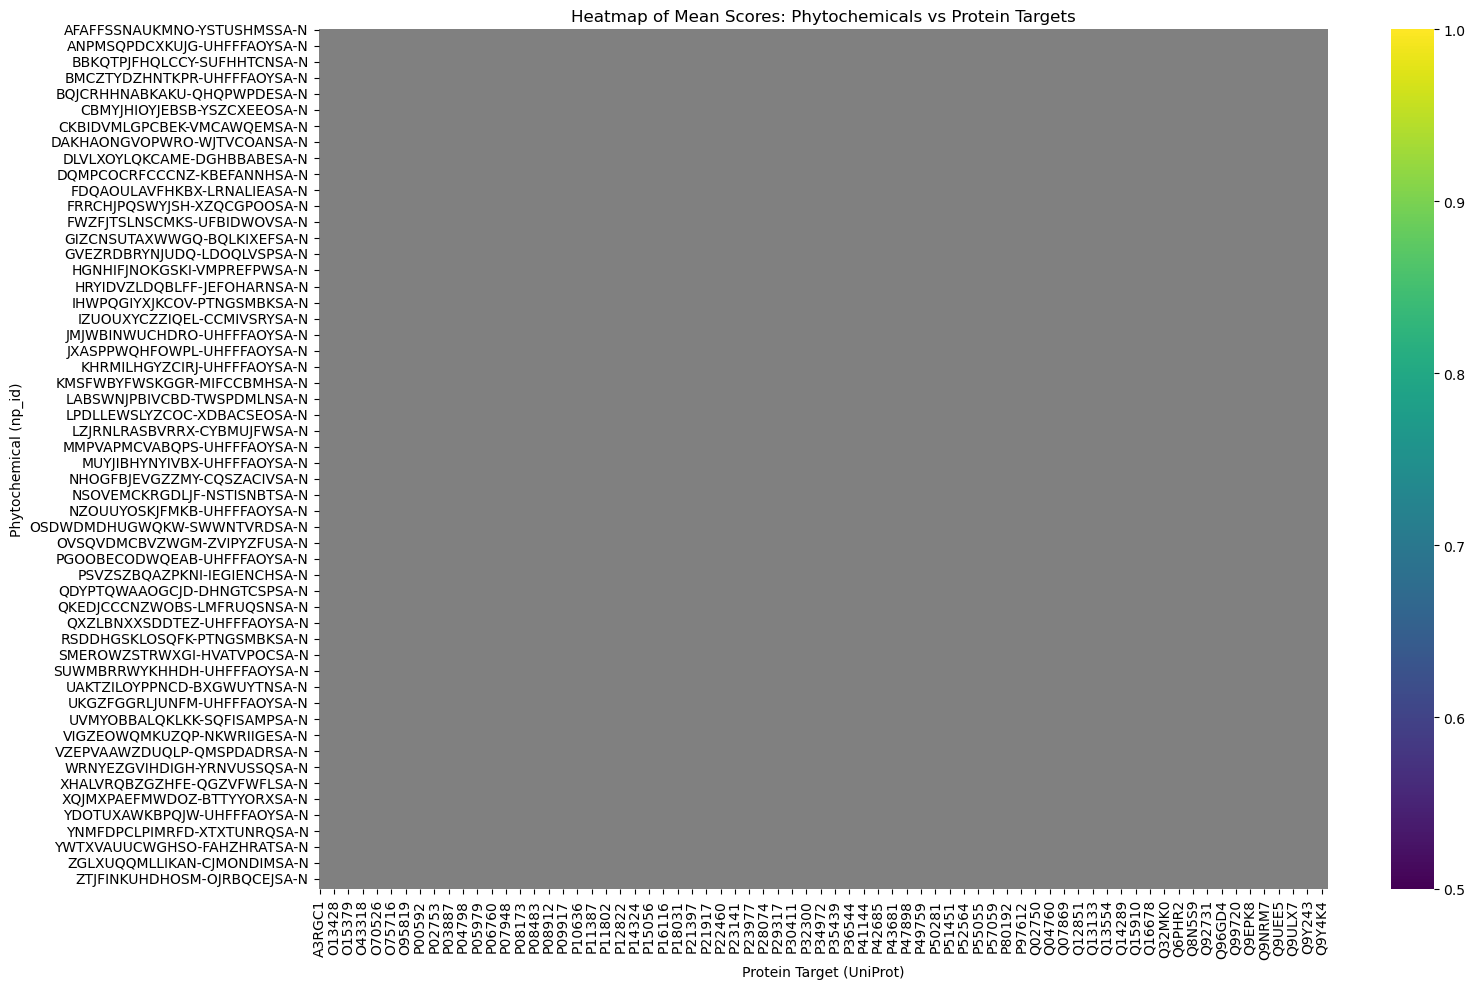

In [1]:
#generating heatmap

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("high_confidence_first_5000.csv")

# Create a pivot table:
# - Rows: np_id (phytochemicals)
# - Columns: uniprot (protein targets)
# - Values: mean_score
heatmap_data = df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
)

# Plot the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.1, linecolor='gray')
plt.title('Heatmap of Mean Scores: Phytochemicals vs Protein Targets')
plt.xlabel('Protein Target (UniProt)')
plt.ylabel('Phytochemical (np_id)')
plt.tight_layout()
plt.show()

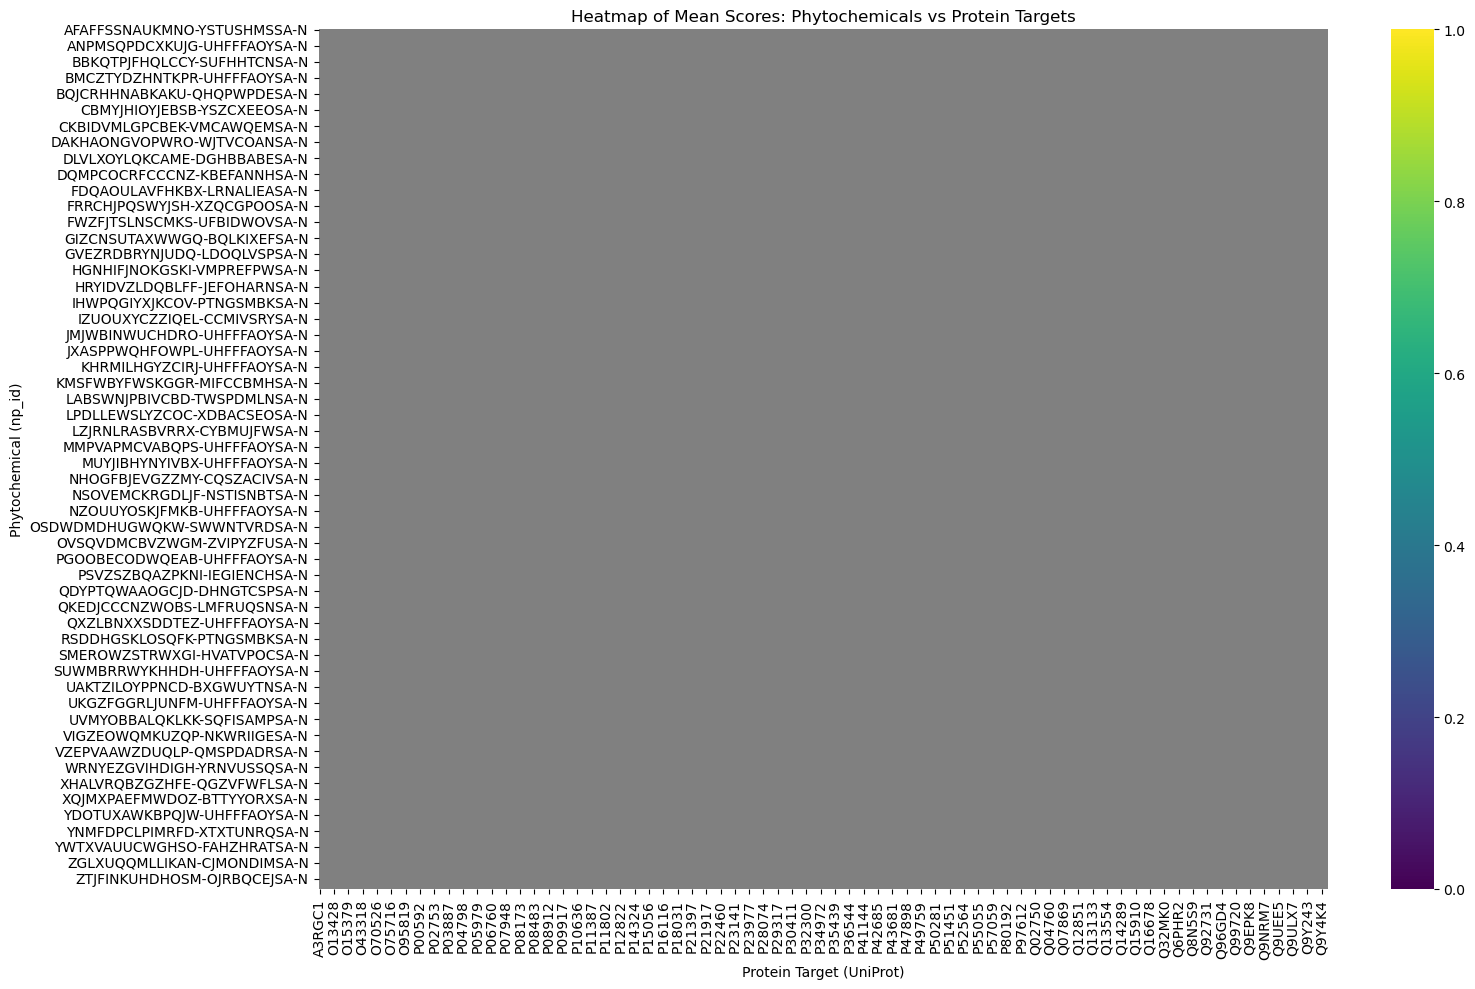

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("high_confidence_first_5000.csv")

# OPTIONAL: Filter for high confidence if needed
# df = df[df['mean_score'] > 0.7]

# Create pivot table
heatmap_data = df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
)

# Fill NaN with 0 for heatmap display
heatmap_data_filled = heatmap_data.fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data_filled, cmap="viridis", linewidths=0.1, linecolor='gray')
plt.title('Heatmap of Mean Scores: Phytochemicals vs Protein Targets')
plt.xlabel('Protein Target (UniProt)')
plt.ylabel('Phytochemical (np_id)')
plt.tight_layout()
plt.show()


Unique phytochemicals (np_id): 483
Unique protein targets (uniprot): 423


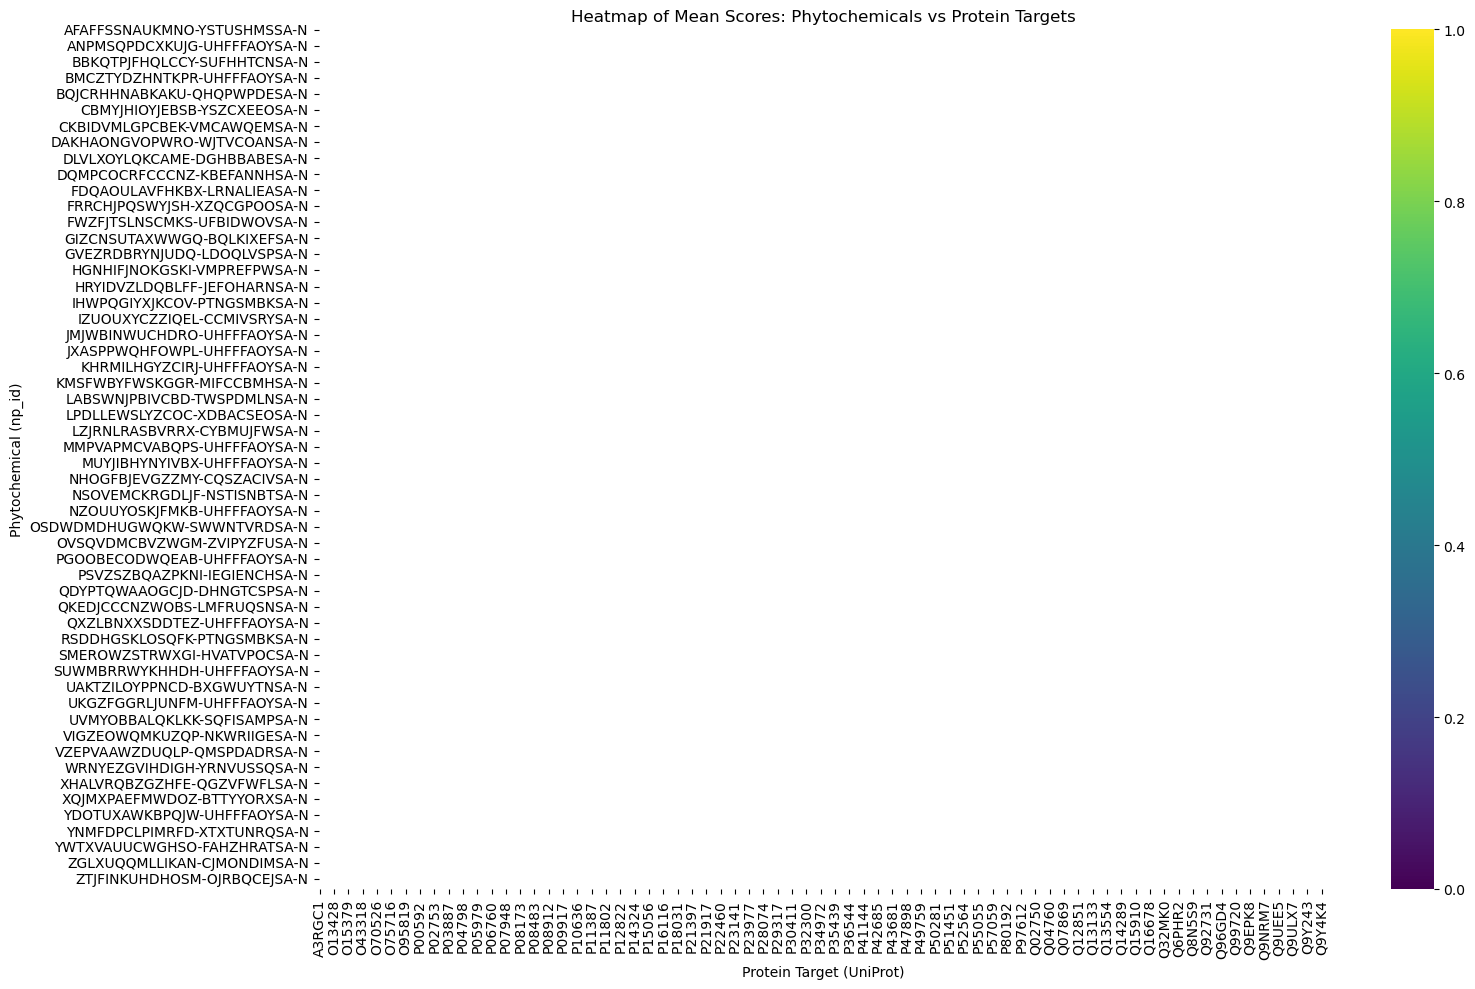

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("high_confidence_first_5000.csv")

# Optional: check unique values
print("Unique phytochemicals (np_id):", df['np_id'].nunique())
print("Unique protein targets (uniprot):", df['uniprot'].nunique())

# Pivot with correct columns
heatmap_data = df.pivot_table(
    index='np_id',           # phytochemical ID
    columns='uniprot',       # protein target ID
    values='mean_score',     # interaction score
    aggfunc='mean'
)

# Fill missing values for plotting
heatmap_data_filled = heatmap_data.fillna(0)

# Plot heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(heatmap_data_filled, cmap="viridis", linewidths=0.1)
plt.title('Heatmap of Mean Scores: Phytochemicals vs Protein Targets')
plt.xlabel('Protein Target (UniProt)')
plt.ylabel('Phytochemical (np_id)')
plt.tight_layout()
plt.show()


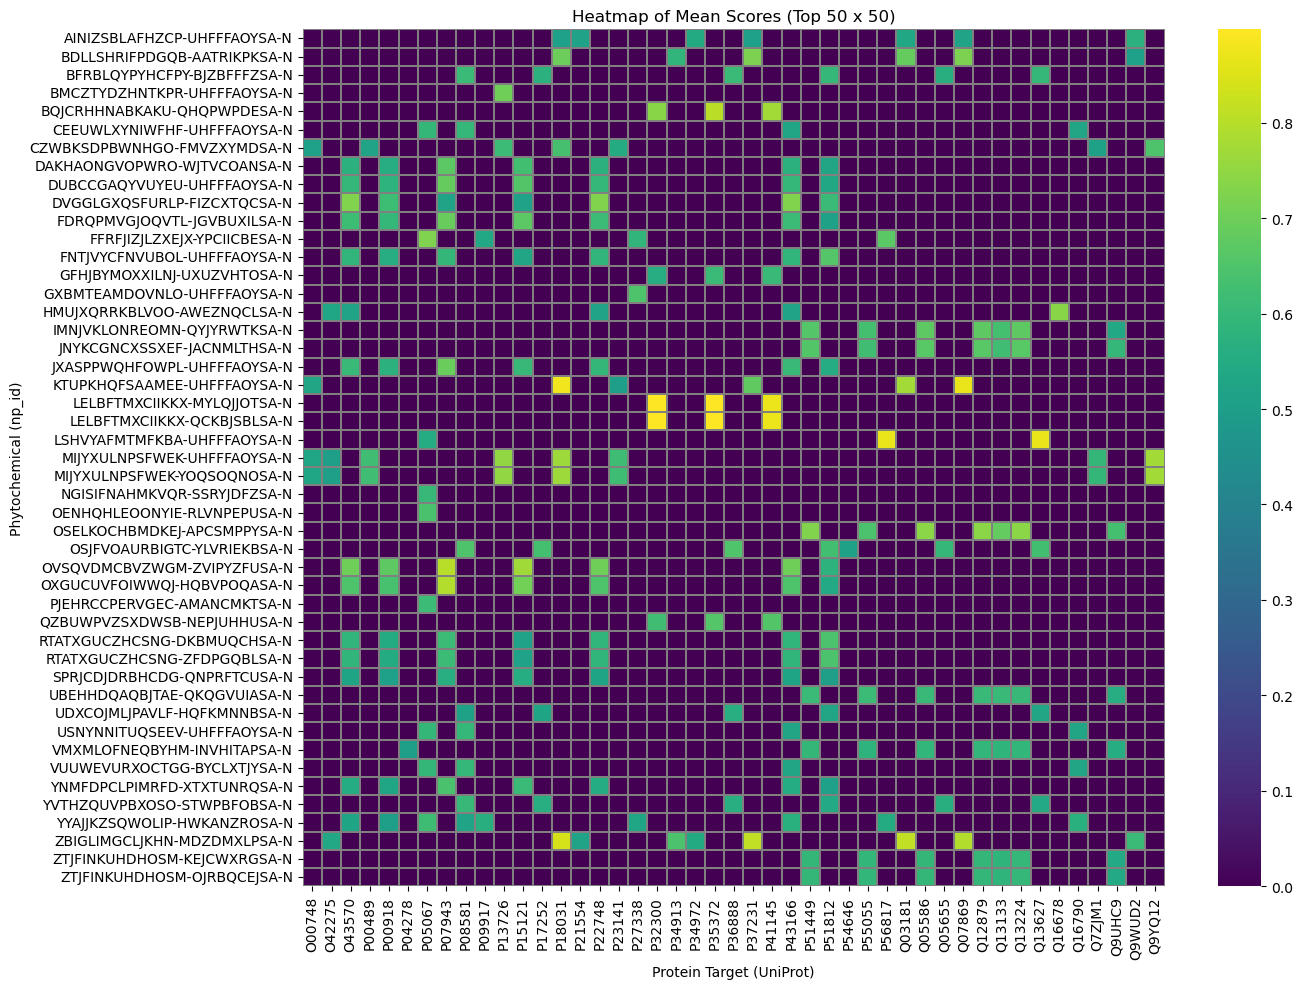

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("high_confidence_first_5000.csv")

# Count top np_id and uniprot with most interactions
top_chemicals = df['np_id'].value_counts().head(50).index
top_proteins = df['uniprot'].value_counts().head(50).index

# Filter data
filtered_df = df[df['np_id'].isin(top_chemicals) & df['uniprot'].isin(top_proteins)]

# Pivot
heatmap_data = filtered_df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
).fillna(0)

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.1, linecolor='gray')
plt.title('Heatmap of Mean Scores (Top 50 x 50)')
plt.xlabel('Protein Target (UniProt)')
plt.ylabel('Phytochemical (np_id)')
plt.tight_layout()
plt.show()


/var/folders/hf/k8cxlyt50fn8c7rnk_g8v1l00000gq/T/ipykernel_83839/695179164.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['binary_interaction'] = (filtered_df['mean_score'] > threshold).astype(int)


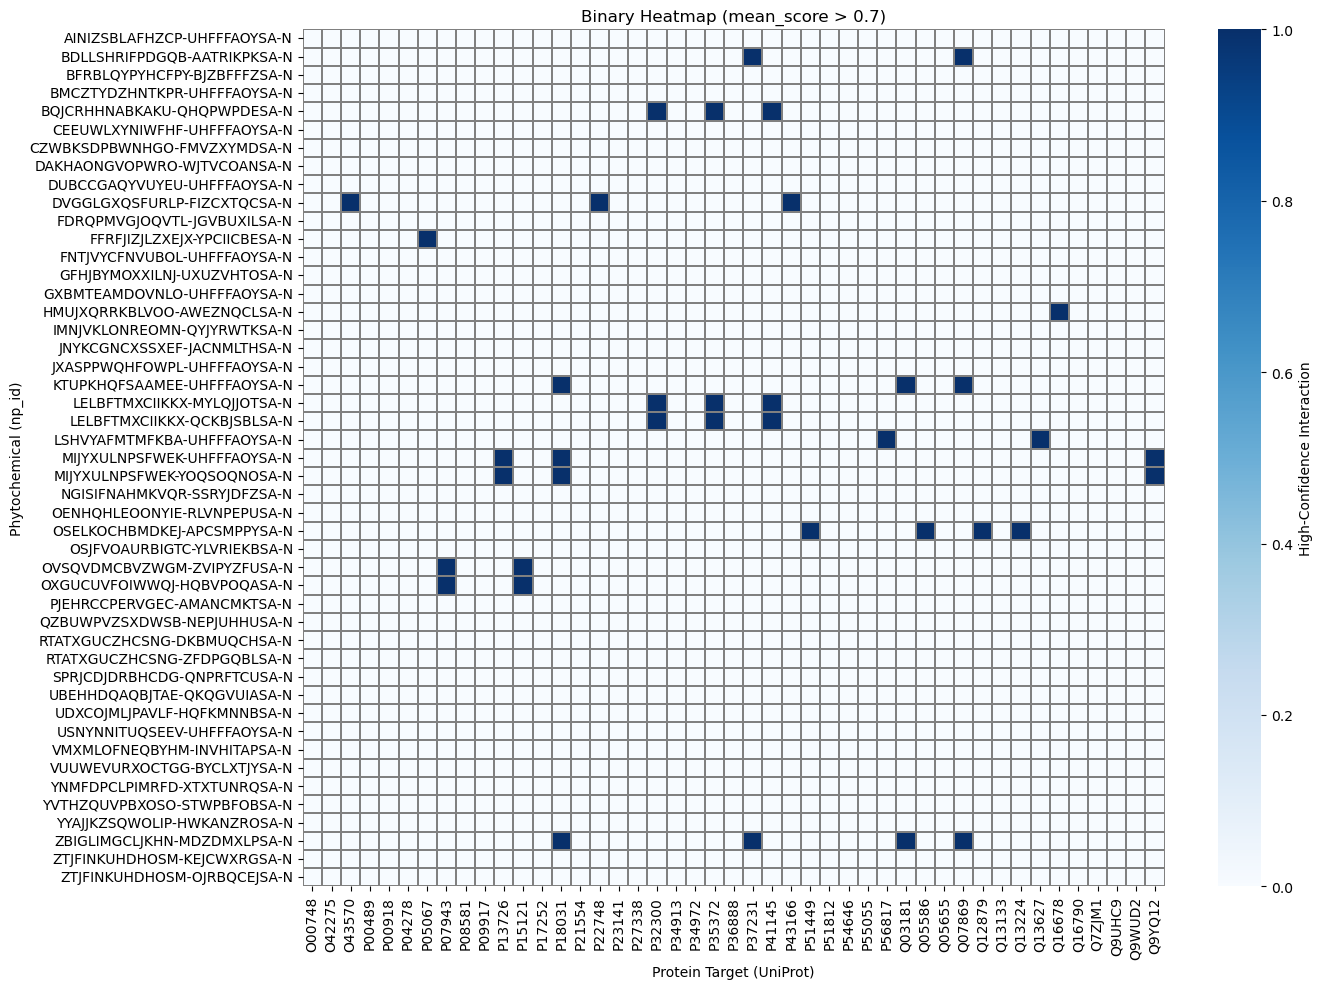

In [9]:
#Binary High-Confidence Heatmap (mean_score > 0.7)
#This version shows a heatmap where:

#1 = strong predicted interaction (score > 0.7)

#0 = no strong interaction

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("high_confidence_first_5000.csv")

# Define high-confidence threshold
threshold = 0.7

# Get top 50 most-connected phytochemicals and targets
top_chemicals = df['np_id'].value_counts().head(50).index
top_proteins = df['uniprot'].value_counts().head(50).index

# Filter dataset
filtered_df = df[df['np_id'].isin(top_chemicals) & df['uniprot'].isin(top_proteins)]

# Binarize the mean_score column
filtered_df['binary_interaction'] = (filtered_df['mean_score'] > threshold).astype(int)

# Create binary pivot table
binary_heatmap = filtered_df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='binary_interaction',
    aggfunc='max'  # Use max in case of duplicates
).fillna(0)

# Plot
plt.figure(figsize=(14, 10))
sns.heatmap(binary_heatmap, cmap="Blues", linewidths=0.1, linecolor='gray', cbar_kws={"label": "High-Confidence Interaction"})
plt.title(f'Binary Heatmap (mean_score > {threshold})')
plt.xlabel('Protein Target (UniProt)')
plt.ylabel('Phytochemical (np_id)')
plt.tight_layout()
plt.show()



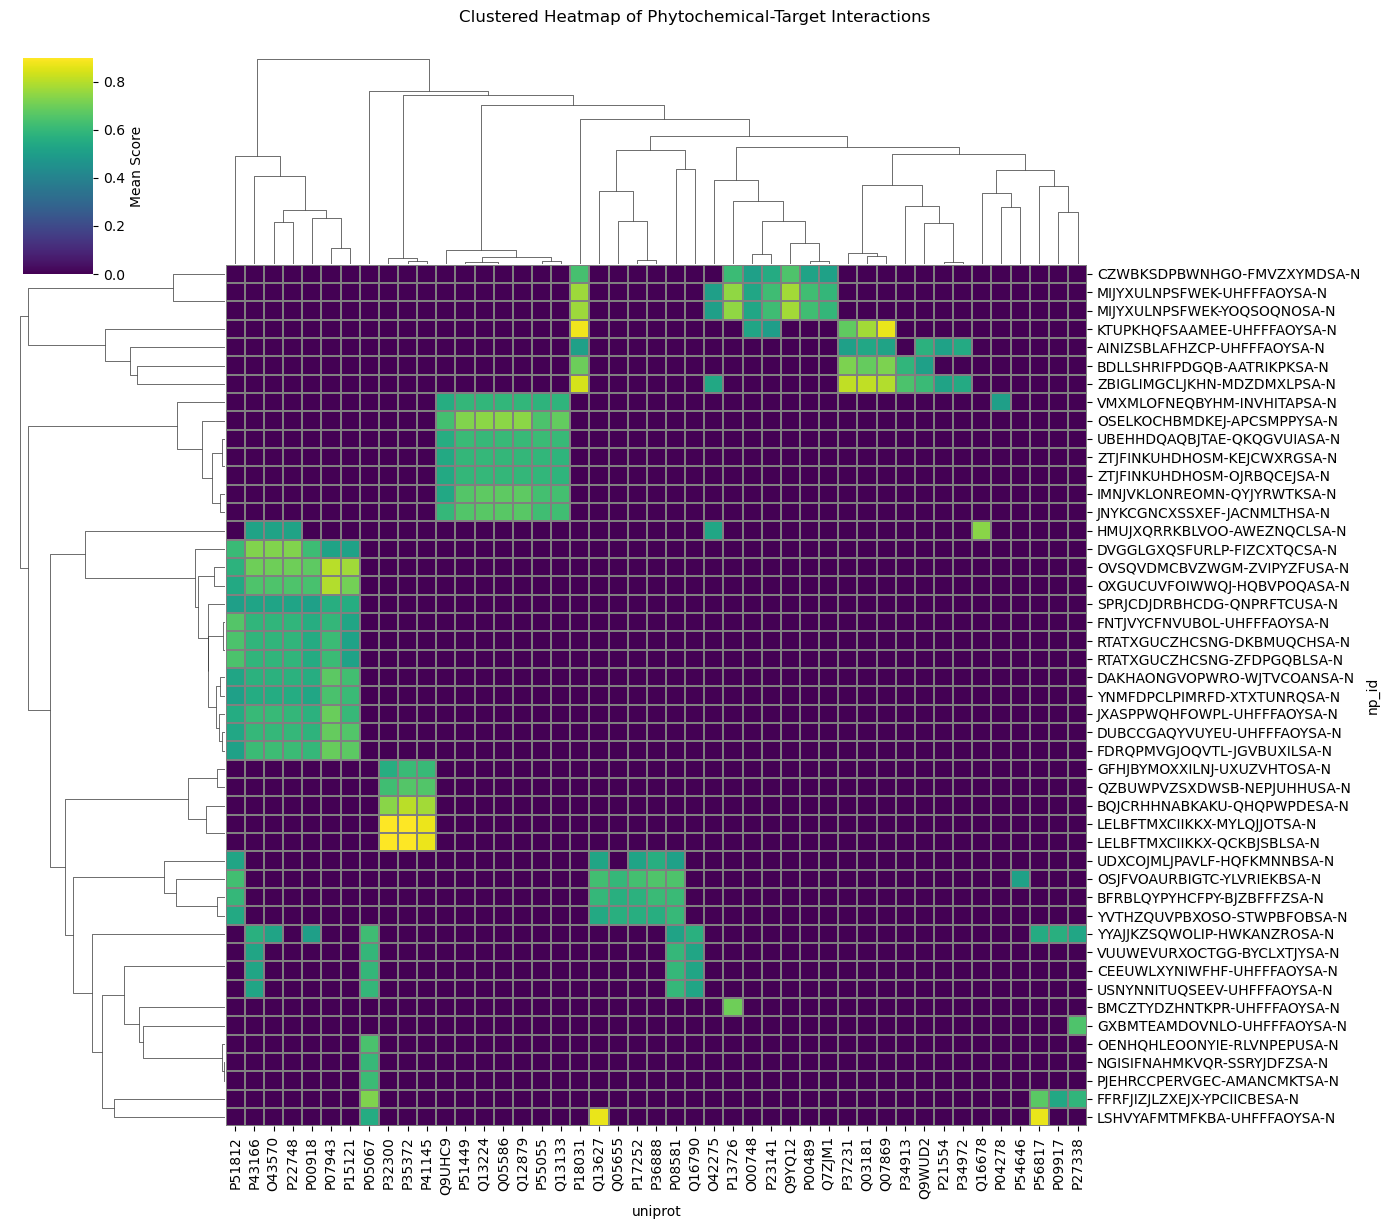

In [11]:
#Clustered Heatmap (Clustermap)
#This version automatically clusters similar rows and columns

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("high_confidence_first_5000.csv")

# Same filtering logic
top_chemicals = df['np_id'].value_counts().head(50).index
top_proteins = df['uniprot'].value_counts().head(50).index
filtered_df = df[df['np_id'].isin(top_chemicals) & df['uniprot'].isin(top_proteins)]

# Pivot table with mean scores
heatmap_data = filtered_df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
).fillna(0)

# Clustered heatmap
sns.clustermap(
    heatmap_data,
    cmap="viridis",
    figsize=(14, 12),
    linewidths=0.1,
    linecolor='gray',
    cbar_kws={"label": "Mean Score"},
    metric='euclidean',  # or 'cosine'
    method='average'     # hierarchical clustering method
)
plt.suptitle("Clustered Heatmap of Phytochemical-Target Interactions", y=1.02)
plt.show()


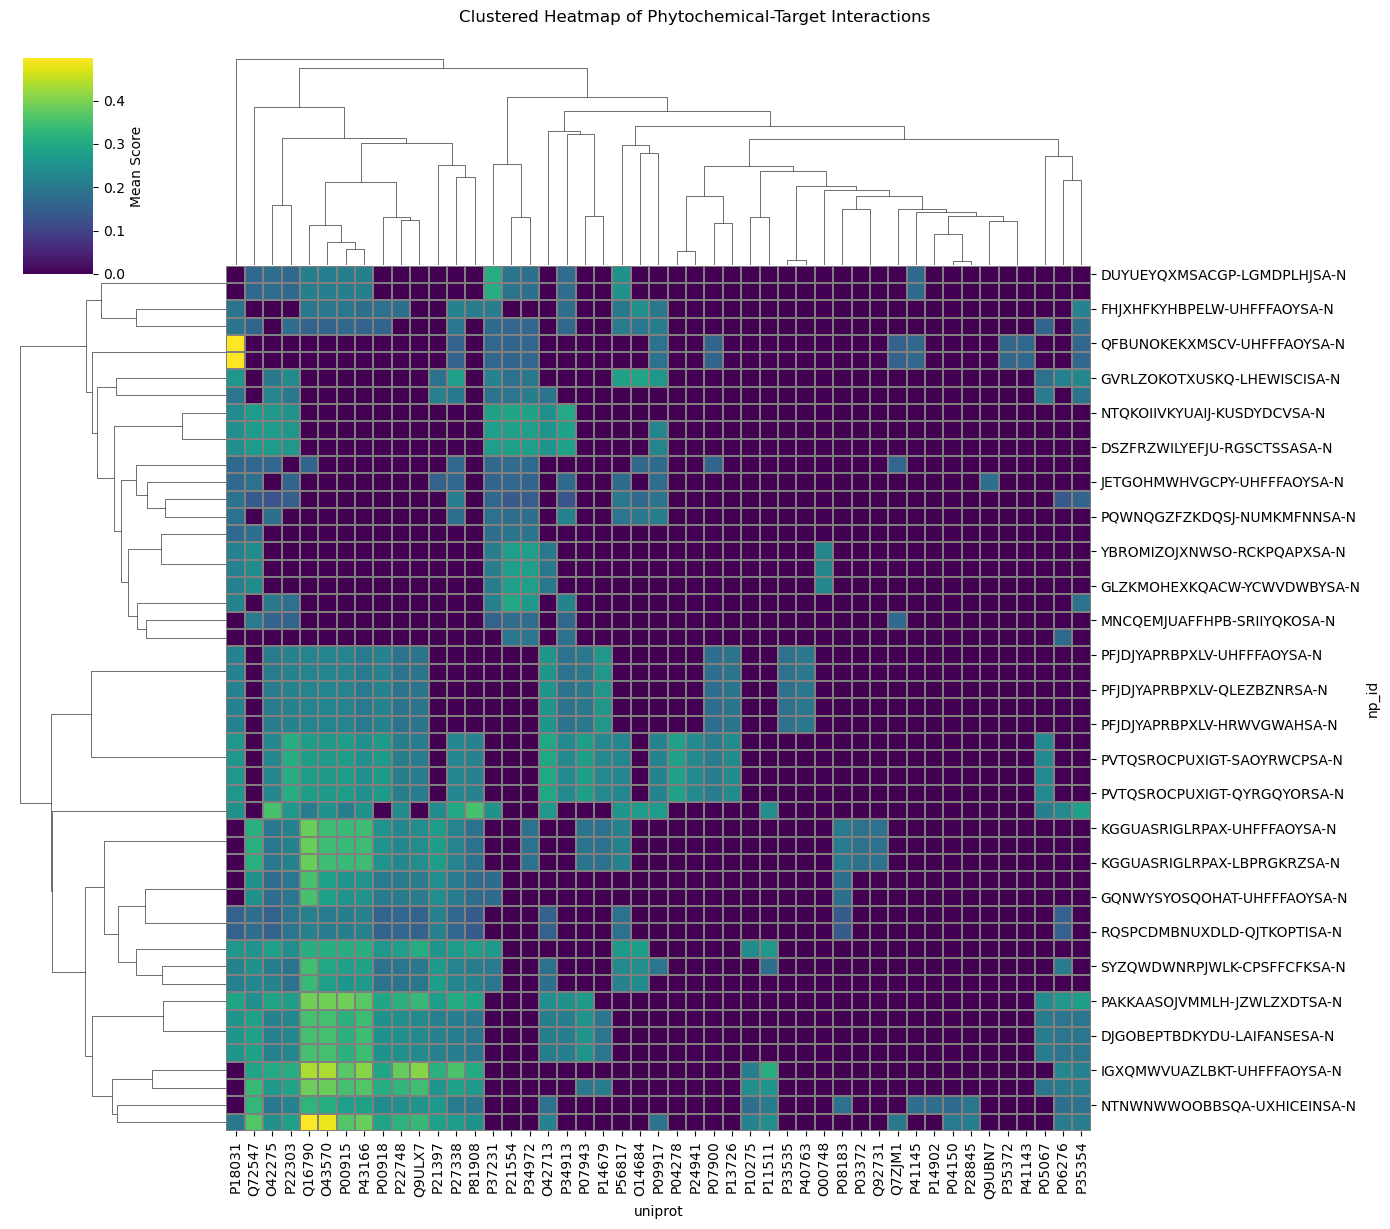

In [13]:
#Clustered Heatmap (Clustermap)
#This version automatically clusters similar rows and columns

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv("cta_predictions_all_phytotherapies.csv")

# Same filtering logic
top_chemicals = df['np_id'].value_counts().head(50).index
top_proteins = df['uniprot'].value_counts().head(50).index
filtered_df = df[df['np_id'].isin(top_chemicals) & df['uniprot'].isin(top_proteins)]

# Pivot table with mean scores
heatmap_data = filtered_df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
).fillna(0)

# Clustered heatmap
sns.clustermap(
    heatmap_data,
    cmap="viridis",
    figsize=(14, 12),
    linewidths=0.1,
    linecolor='gray',
    cbar_kws={"label": "Mean Score"},
    metric='euclidean',  # or 'cosine'
    method='average'     # hierarchical clustering method
)
plt.suptitle("Clustered Heatmap of Phytochemical-Target Interactions", y=1.02)
plt.show()


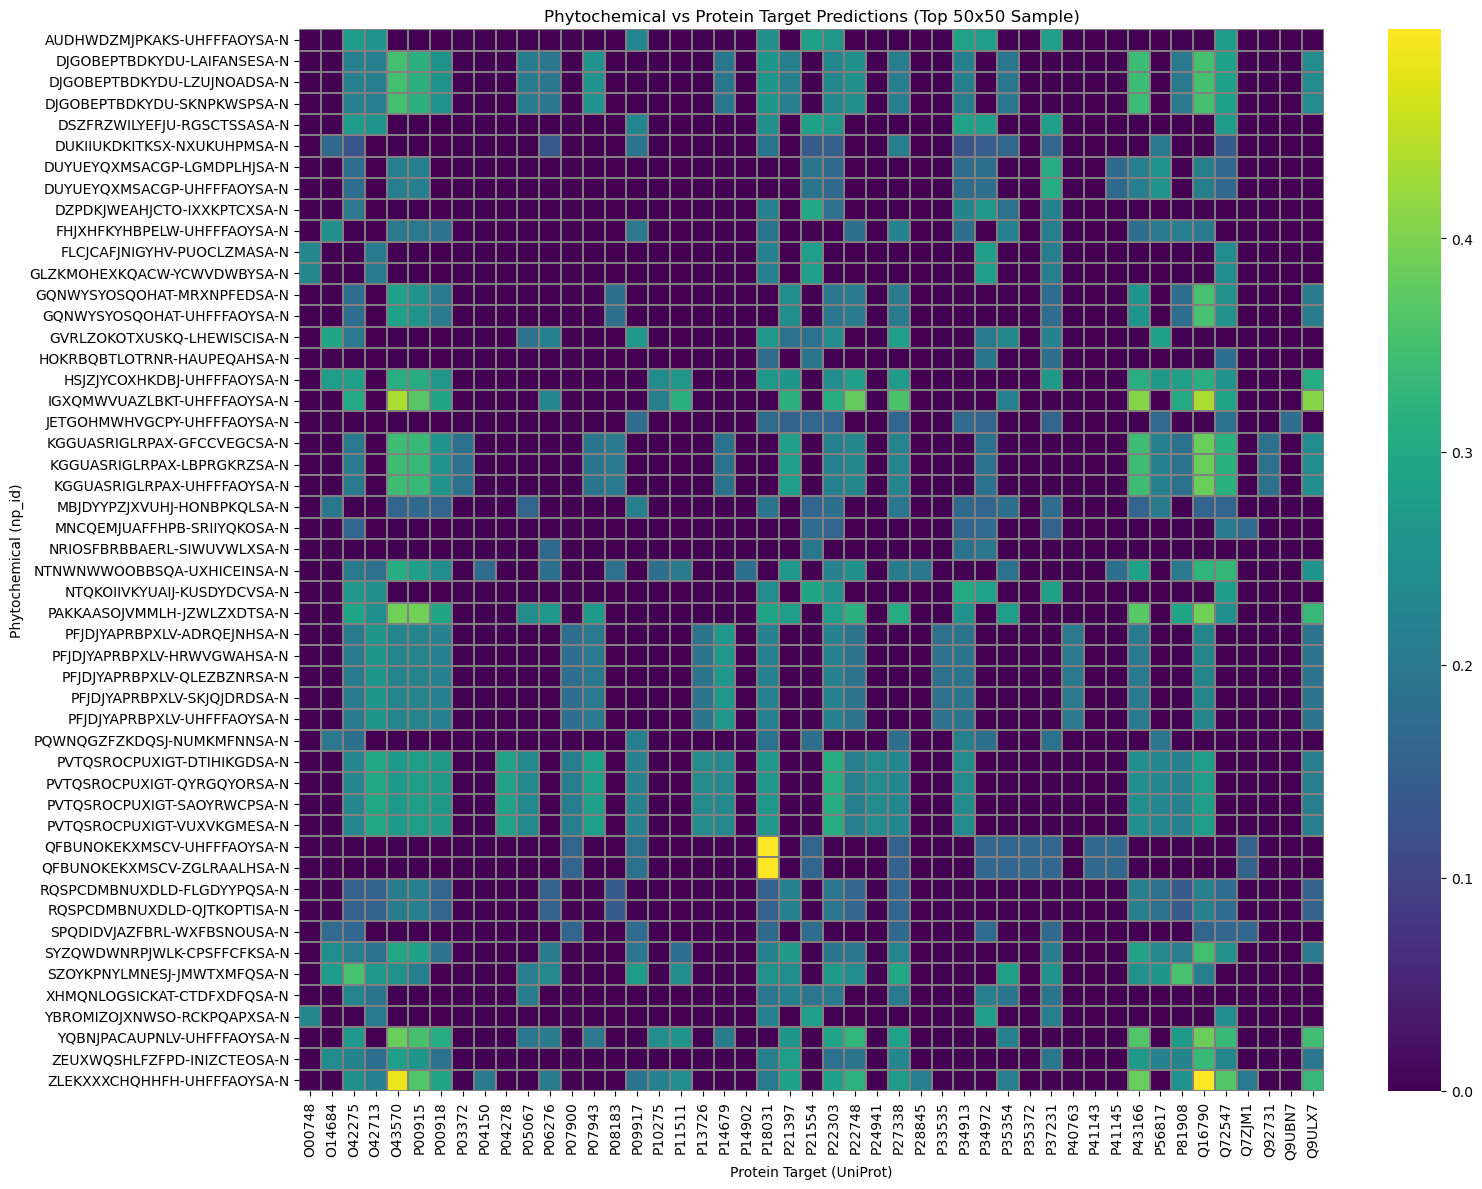

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# STEP 1: Load a sample from the large CSV
df = pd.read_csv("cta_predictions_all_phytotherapies.csv")  # Adjust nrows for speed vs. coverage

# STEP 2: Identify top 50 np_ids and top 50 uniprot targets by frequency
top_np_ids = df['np_id'].value_counts().head(50).index
top_uniprots = df['uniprot'].value_counts().head(50).index

# STEP 3: Filter the dataframe to those top 50 x 50 entities
filtered_df = df[df['np_id'].isin(top_np_ids) & df['uniprot'].isin(top_uniprots)]

# STEP 4: Pivot into a matrix for heatmap (np_id x uniprot with mean_score)
heatmap_data = filtered_df.pivot_table(
    index='np_id',
    columns='uniprot',
    values='mean_score',
    aggfunc='mean'
).fillna(0)

# STEP 5: Plot the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(heatmap_data, cmap="viridis", linewidths=0.1, linecolor='gray')
plt.title("Phytochemical vs Protein Target Predictions (Top 50x50 Sample)")
plt.xlabel("Protein Target (UniProt)")
plt.ylabel("Phytochemical (np_id)")
plt.tight_layout()
plt.show()


In [27]:
pip install pandas requests tqdm

Note: you may need to restart the kernel to use updated packages.


In [29]:
import pandas as pd
import requests
from tqdm import tqdm

# Load your file
file_path = "cta_predictions_all_phytotherapies.csv"
df = pd.read_csv(file_path)

# Limit to top 50x50 if needed
top_np_ids = df['np_id'].value_counts().head(50).index
top_uniprots = df['uniprot'].value_counts().head(50).index
top_df = df[df['np_id'].isin(top_np_ids) & df['uniprot'].isin(top_uniprots)].copy()

# --- PART 1: InChIKey to compound name via PubChem API ---
def inchi_to_name(inchikey):
    url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/inchikey/{inchikey}/property/Title/JSON"
    try:
        r = requests.get(url, timeout=5)
        return r.json()['PropertyTable']['Properties'][0]['Title']
    except:
        return None

compound_name_map = {}
for inchikey in tqdm(top_df['np_id'].unique(), desc="Resolving InChIKeys"):
    compound_name_map[inchikey] = inchi_to_name(inchikey)

top_df['compound_name'] = top_df['np_id'].map(compound_name_map)

# --- PART 2: UniProt ID to protein name/function via UniProt API ---
def uniprot_to_name(uniprot_id):
    url = f"https://rest.uniprot.org/uniprotkb/{uniprot_id}.json"
    try:
        r = requests.get(url, timeout=5)
        data = r.json()
        name = data.get('proteinDescription', {}).get('recommendedName', {}).get('fullName', {}).get('value')
        return name
    except:
        return None

protein_name_map = {}
for uid in tqdm(top_df['uniprot'].unique(), desc="Resolving UniProt IDs"):
    protein_name_map[uid] = uniprot_to_name(uid)

top_df['protein_name'] = top_df['uniprot'].map(protein_name_map)

# --- PART 3: ChEMBL Target ID to ATC code (optional) ---
def chembl_target_to_atc(chembl_id):
    url = f"https://www.ebi.ac.uk/chembl/api/data/target/{chembl_id}.json"
    try:
        r = requests.get(url, timeout=5)
        return r.json().get("target_components", [{}])[0].get("accession")
    except:
        return None

atc_map = {}
for tid in tqdm(top_df['target_chembl_id'].unique(), desc="Resolving ChEMBL targets"):
    atc_map[tid] = chembl_target_to_atc(tid)

top_df['atc_code'] = top_df['target_chembl_id'].map(atc_map)

# --- Save Enriched Data ---
top_df.to_csv("top50x50_enriched_for_heatmap.csv", index=False)
print("✅ Enriched data saved to 'top50x50_enriched_for_heatmap.csv'")


Resolving ChEMBL targets: 100%|█████████████████| 49/49 [02:29<00:00,  3.05s/it]

✅ Enriched data saved to 'top50x50_enriched_for_heatmap.csv'


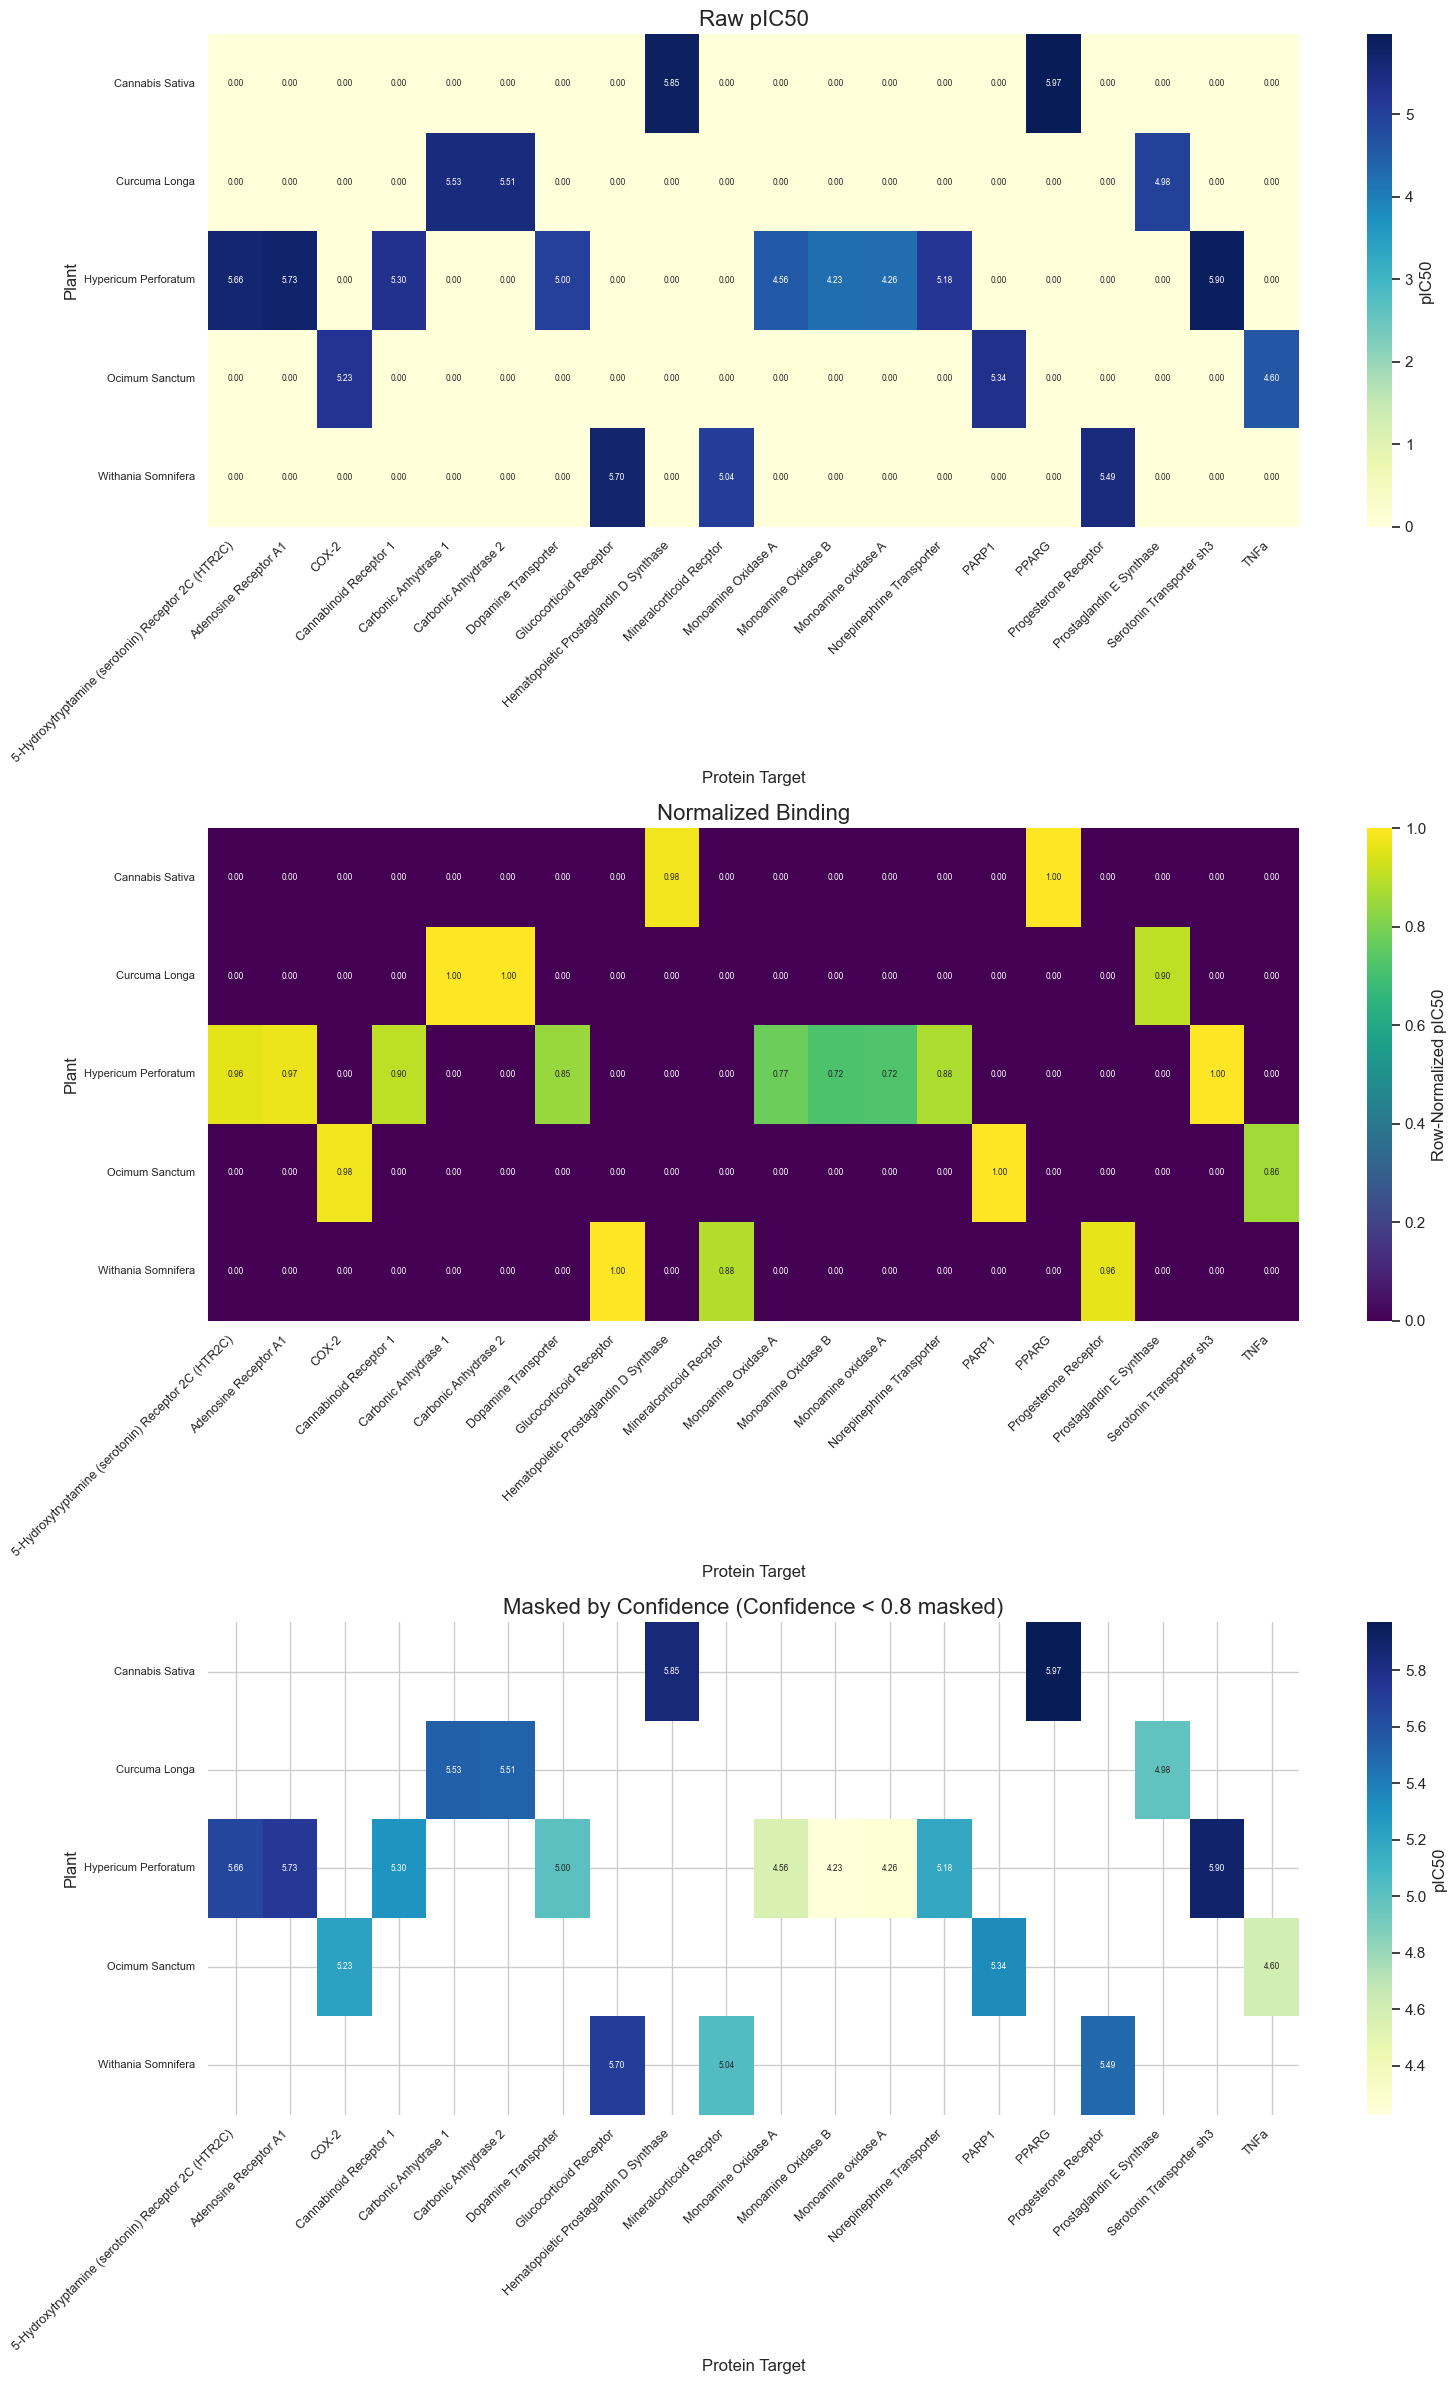

In [103]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv("Phytotherapy Docking Results From Selected Plants 240e7f9c0f2380ebbf05d32aa5fca9c5.csv")

# Compute pIC50
df["pIC50"] = 6 - df["Binding Affinity (log(IC50 [uM]))"]

# Pivot tables
pivot_raw = df.pivot_table(index="Plant", columns="Protein Target", values="pIC50", aggfunc="mean", fill_value=0)
pivot_norm = pivot_raw.div(pivot_raw.max(axis=1), axis=0).fillna(0)
masked_df = df.copy()
masked_df.loc[masked_df["Confidence Score"] < 0.8, "pIC50"] = np.nan
pivot_masked = masked_df.pivot_table(index="Plant", columns="Protein Target", values="pIC50", aggfunc="mean")

# Plot: vertical stack
fig, axs = plt.subplots(3, 1, figsize=(16, 24))  # Width x Height

# Raw pIC50
sns.heatmap(pivot_raw, cmap="YlGnBu", annot=True, fmt=".2f", ax=axs[0],
            annot_kws={"size": 6}, cbar_kws={"label": "pIC50"})
axs[0].set_title("Raw pIC50", fontsize=16)
axs[0].set_ylabel("Plant", fontsize=12)

# Normalized Binding
sns.heatmap(pivot_norm, cmap="viridis", annot=True, fmt=".2f", ax=axs[1],
            annot_kws={"size": 6}, cbar_kws={"label": "Row-Normalized pIC50"})
axs[1].set_title("Normalized Binding", fontsize=16)
axs[1].set_ylabel("Plant", fontsize=12)

# Masked by Confidence
sns.heatmap(pivot_masked, cmap="YlGnBu", annot=True, fmt=".2f", ax=axs[2],
            annot_kws={"size": 6}, cbar_kws={"label": "pIC50"})
axs[2].set_title("Masked by Confidence (Confidence < 0.8 masked)", fontsize=16)
axs[2].set_ylabel("Plant", fontsize=12)

# Improve tick readability
for ax in axs:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

# Layout and save
plt.tight_layout()
plt.savefig("vertical_combined_heatmaps_highres.png", dpi=600, bbox_inches="tight")
plt.show()
